# Plotting EMS stuff

First of all, we are going to plot the data we have from the EMS. We have the following data:

In [1]:
from typing import Any

import numpy as np
from numpy import ndarray
import matplotlib.pyplot as plt
import torch
import matplotlib
import matplotlib.dates as mdates
import datetime

from utils_functions.funcionesEMS import *
from gymnasium import spaces
from environments.custom_env import Custom_env
from environments.EMS_env import EMS_env
import joblib
import pandas as pd
%matplotlib inline

In [2]:
timesteps = 144
time = range(timesteps)
x = np.array([datetime.datetime(2021, 1, 1, i, j) for i in range(24) for j in range(0, 60, 10)])
a = get_rad()
c = get_temperatura()
p_fv = solar_power(a, c)
b = get_demand()
%matplotlib inline

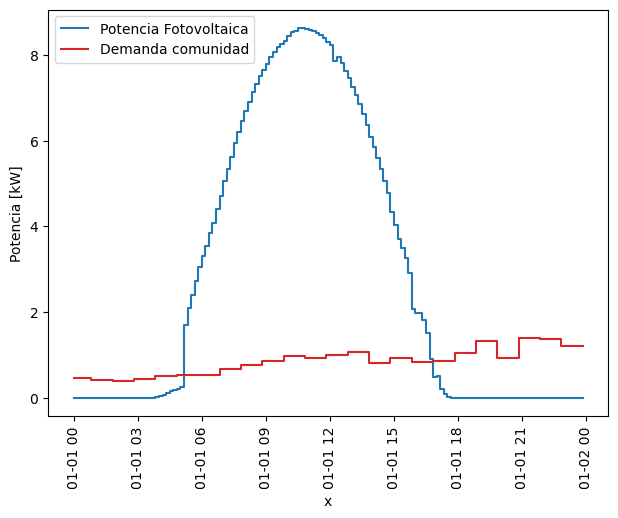

In [3]:
fig, ax = plt.subplots(dpi=100)
i = 0
# Plot the first curve and set its y label
delay = 0
color = 'tab:blue'
ax.set_xlabel('x')
ax.set_ylabel('Potencia [kW]')
ax.step(x, p_fv[timesteps*i+delay:timesteps*(i+1)+delay], color=color, label = 'Potencia Fotovoltaica')


# Create a second y-axis and plot the second curve on it
color = 'tab:red'
ax.step(x, b[timesteps*i+delay:timesteps*(i+1)+delay], color=color, label = 'Demanda comunidad')
ax.legend(loc='upper left')

fig.tight_layout()
plt.xticks(rotation=90)
plt.show()

In [4]:
path1 = 'training_results/ems/DQN_20240320_011536'
path2 = 'training_results/ems/DQN_20240320_013758'
path3 = 'training_results/ems/DQN_20240320_020058'

training_results1 = pd.read_csv(path1 + '/training_results.csv')
training_results2 = pd.read_csv(path2 + '/training_results.csv')
training_results3 = pd.read_csv(path3 + '/training_results.csv')

## Showing the results of the training

### agent 1

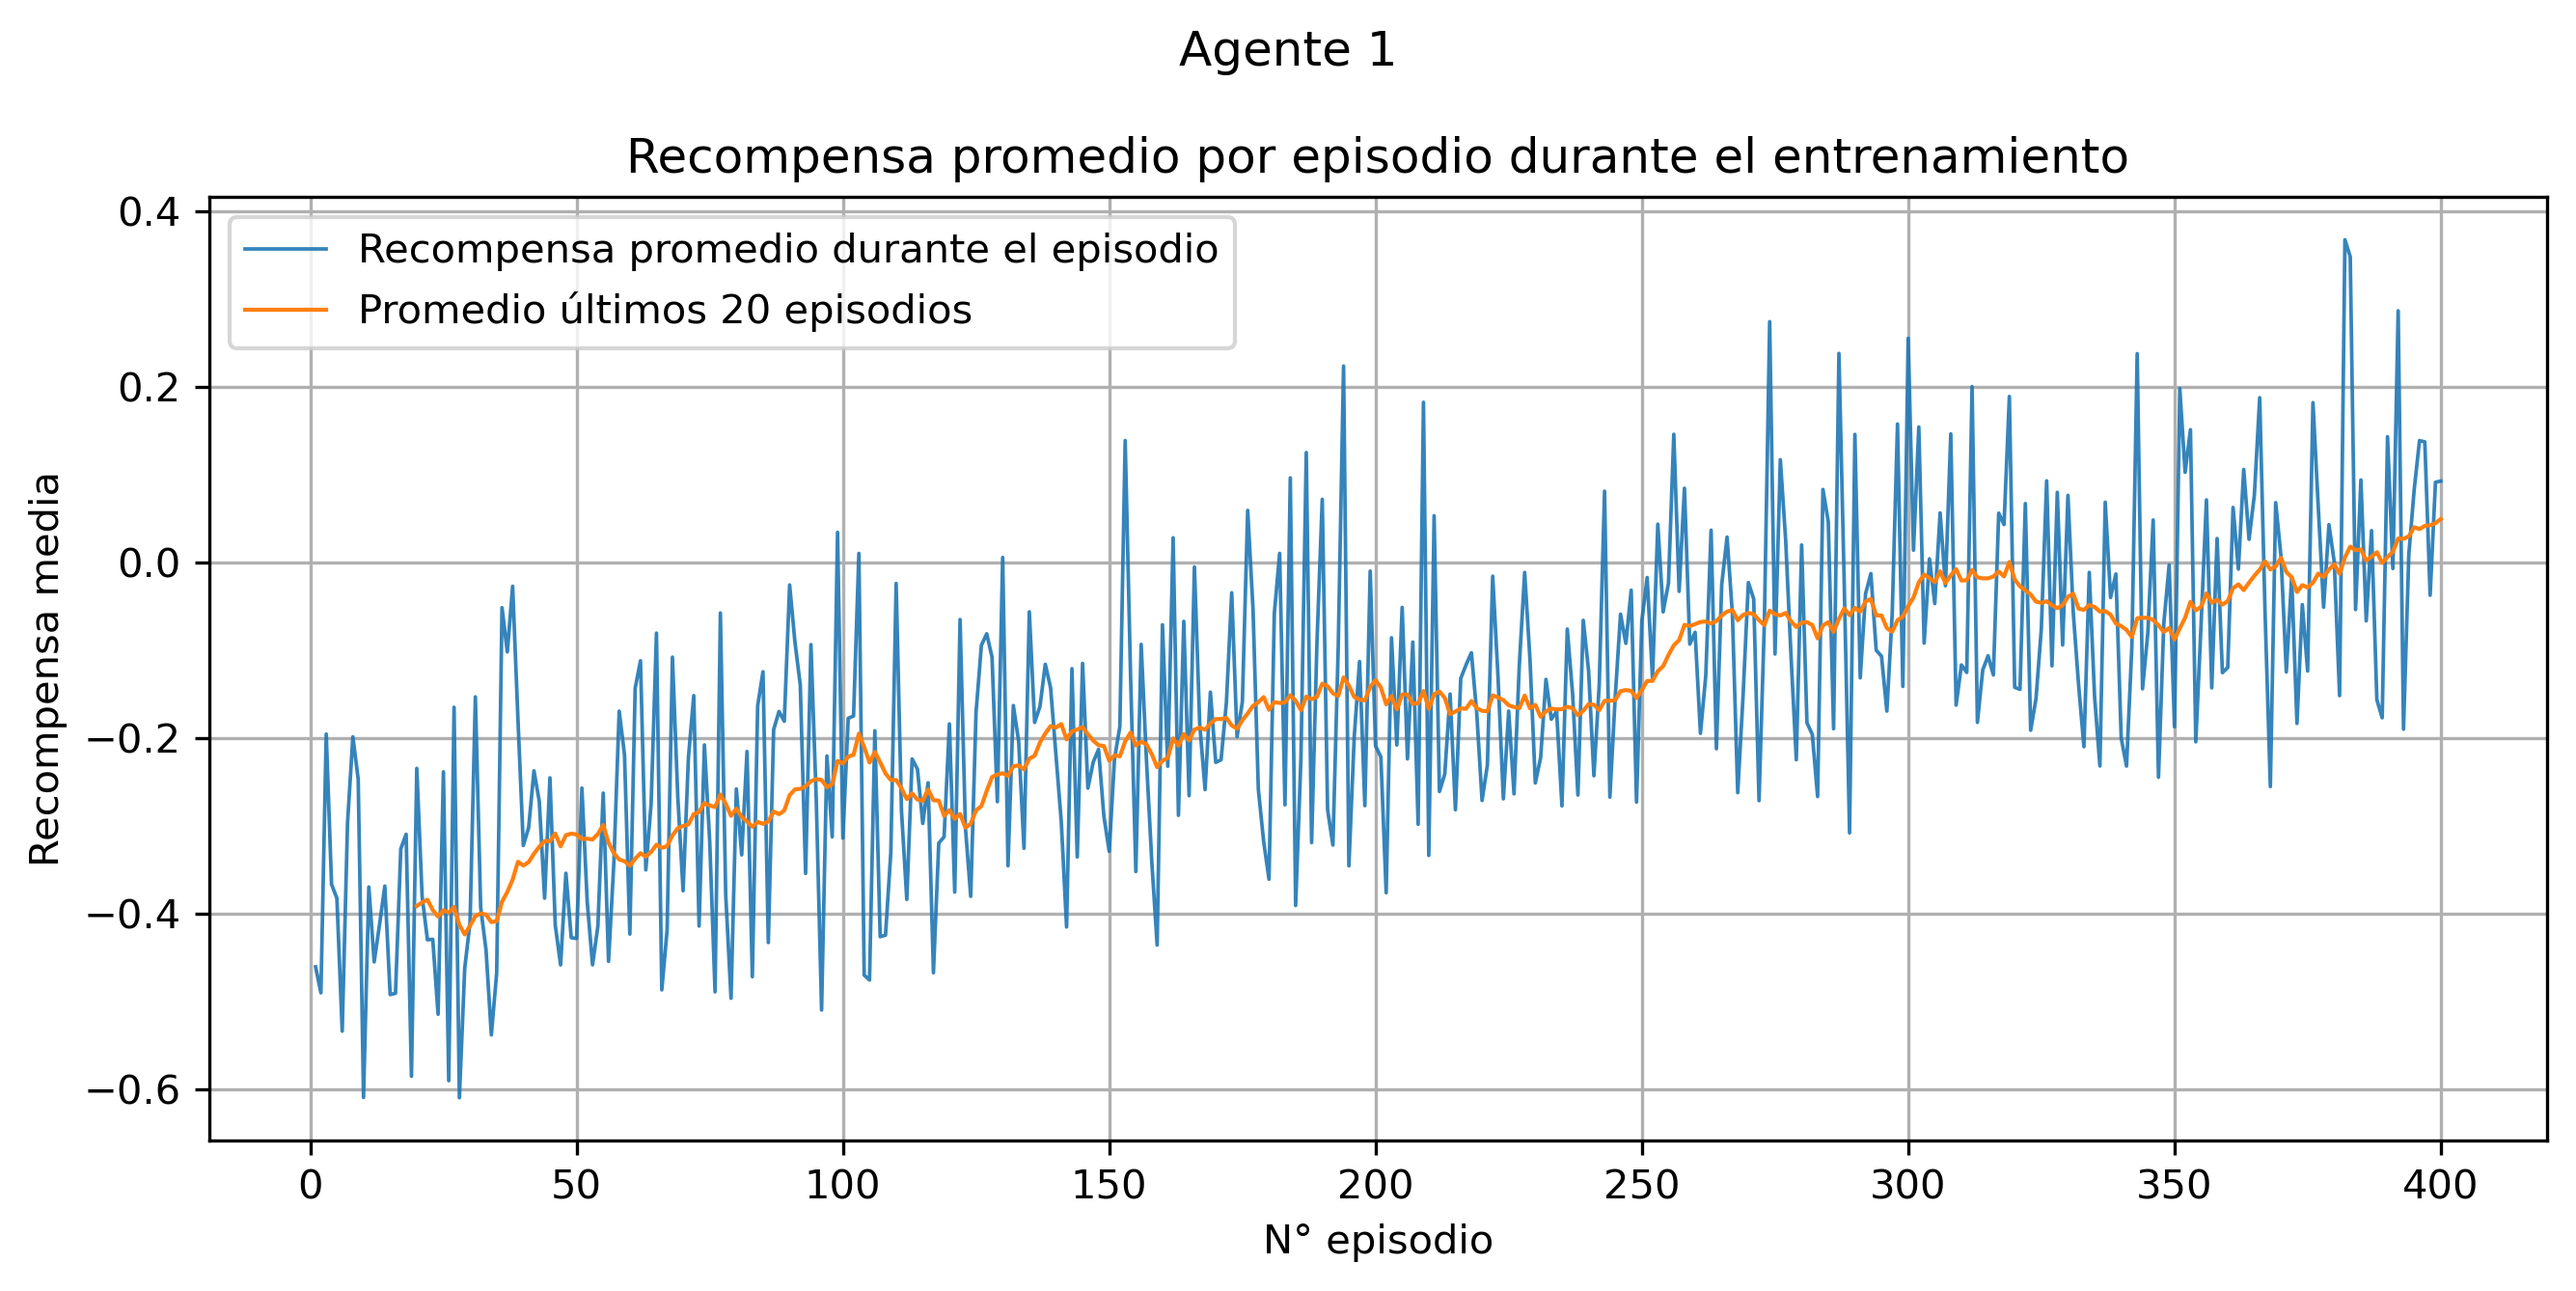

In [5]:
rwd = training_results1["mean_episode_rewards"].to_numpy()
mean_rwd = np.convolve(rwd, np.ones(20)/20, mode='valid')
N = len(rwd)
fig = plt.figure(dpi=300)
fig.set_size_inches(9.0, 4.5)
plt.plot(range(1,N+1), rwd,  label="Recompensa promedio durante el episodio", alpha=0.9, linewidth = .9)
plt.plot(range(1+19, N+1),mean_rwd, label="Promedio últimos 20 episodios", linewidth = 1)
plt.legend()
plt.xlabel("N° episodio")
plt.ylabel("Recompensa media")
plt.suptitle("Agente 1")
plt.title("Recompensa promedio por episodio durante el entrenamiento")
plt.grid()
plt.tight_layout()
plt.savefig("./figures/entrenamiento_1.png", dpi=300)

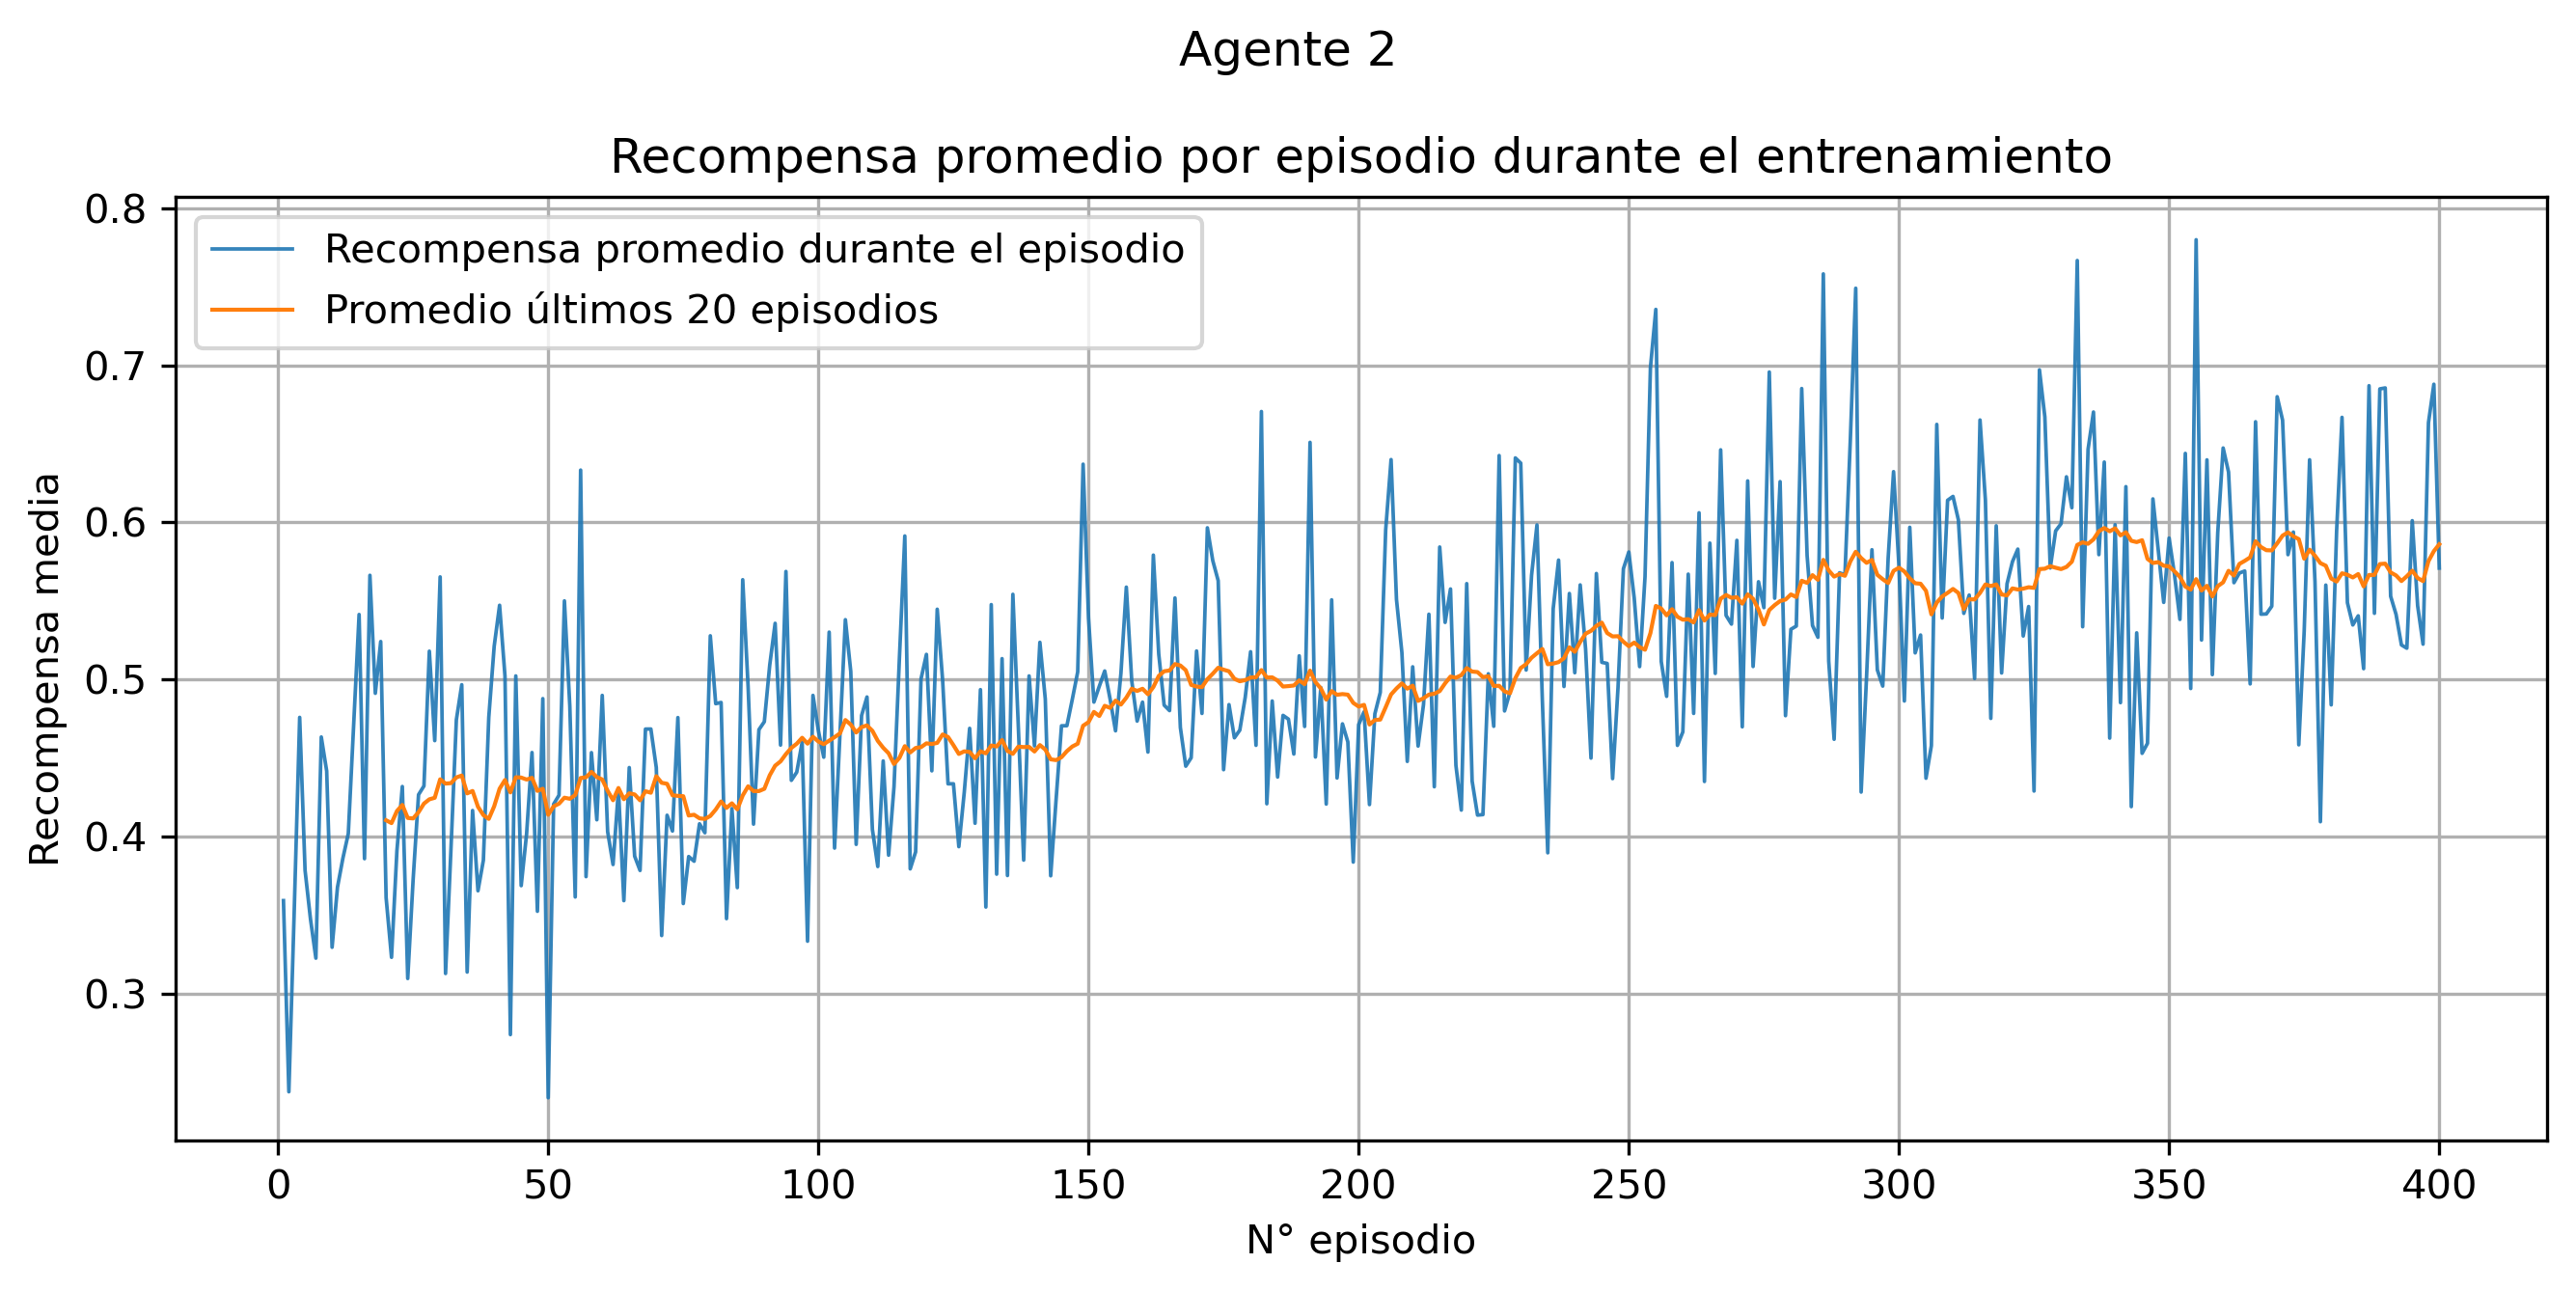

In [6]:
rwd = training_results2["mean_episode_rewards"].to_numpy()
mean_rwd = np.convolve(rwd, np.ones(20)/20, mode='valid')
N = len(rwd)
fig = plt.figure(dpi=300)
fig.set_size_inches(9.0, 4.5)
plt.plot(range(1,N+1), rwd,  label="Recompensa promedio durante el episodio", alpha=0.9, linewidth = .9)
plt.plot(range(1+19, N+1),mean_rwd, label="Promedio últimos 20 episodios", linewidth = 1)
plt.legend()
plt.xlabel("N° episodio")
plt.ylabel("Recompensa media")
plt.suptitle("Agente 2")
plt.title("Recompensa promedio por episodio durante el entrenamiento")
plt.grid()
plt.tight_layout()
plt.savefig("./figures/entrenamiento_2.png", dpi=300)

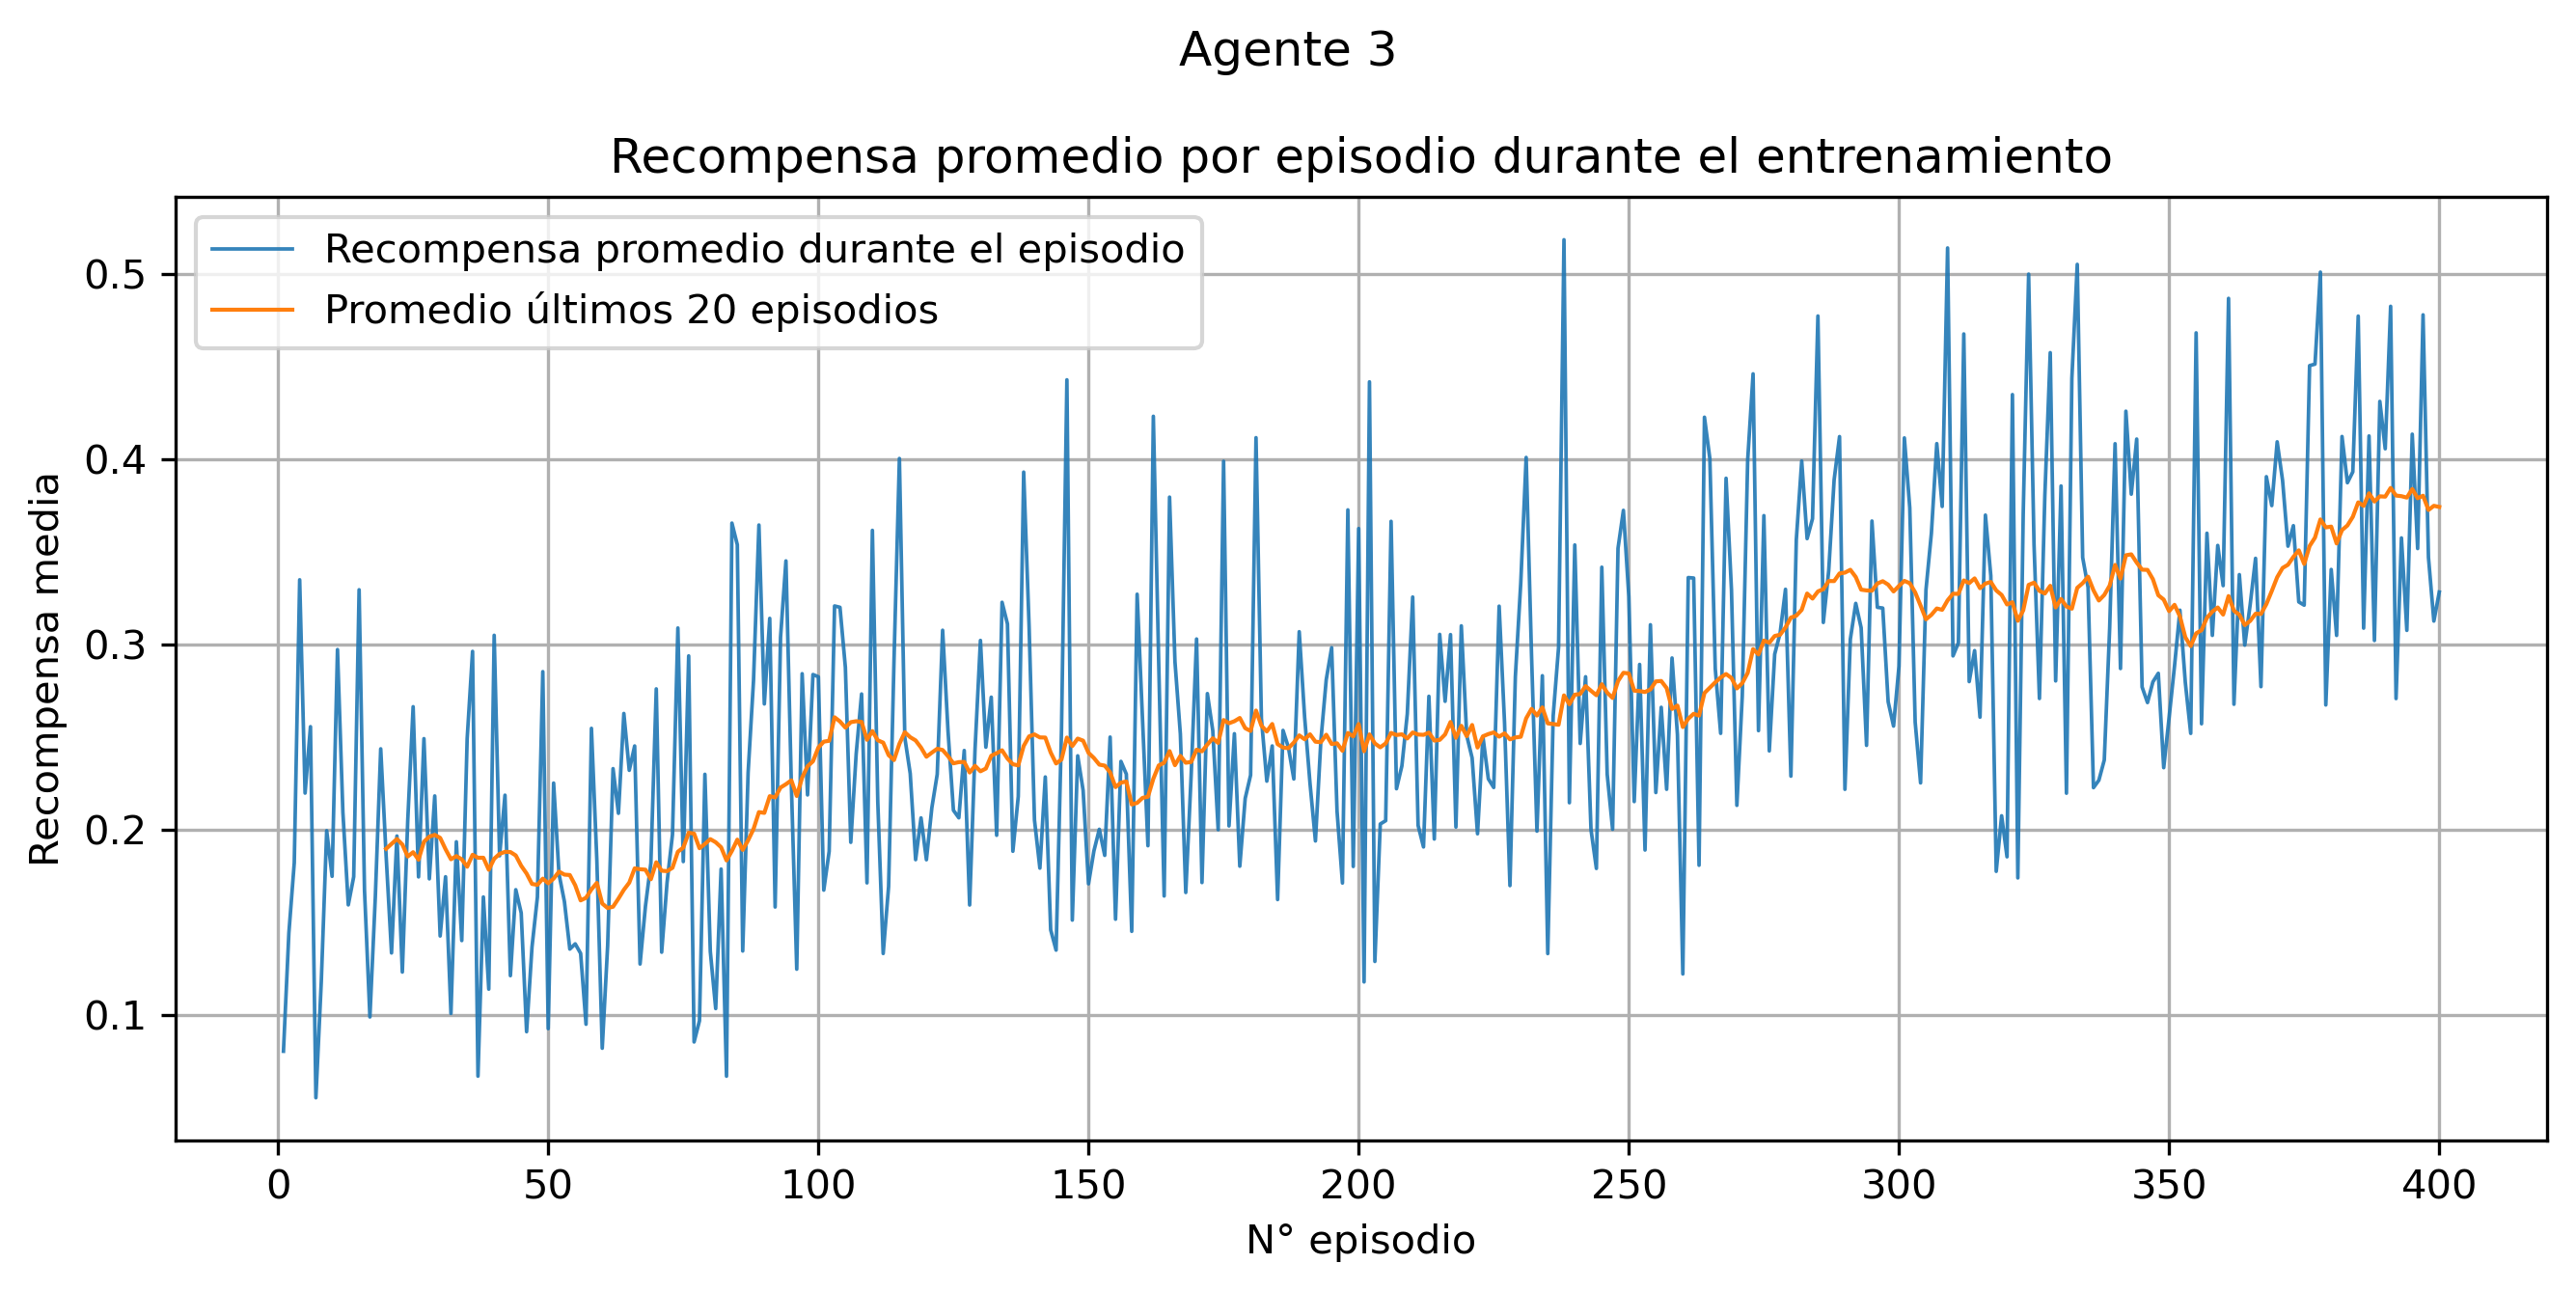

In [7]:
rwd = training_results3["mean_episode_rewards"].to_numpy()
mean_rwd = np.convolve(rwd, np.ones(20)/20, mode='valid')
N = len(rwd)
fig = plt.figure(dpi=300)
fig.set_size_inches(9.0, 4.5)
plt.plot(range(1,N+1), rwd,  label="Recompensa promedio durante el episodio", alpha=0.9, linewidth = .9)
plt.plot(range(1+19, N+1),mean_rwd, label="Promedio últimos 20 episodios", linewidth = 1)
plt.legend()
plt.xlabel("N° episodio")
plt.ylabel("Recompensa media")
plt.suptitle("Agente 3")
plt.title("Recompensa promedio por episodio durante el entrenamiento")
plt.grid()
plt.tight_layout()
plt.savefig("./figures/entrenamiento_3.png", dpi=300)

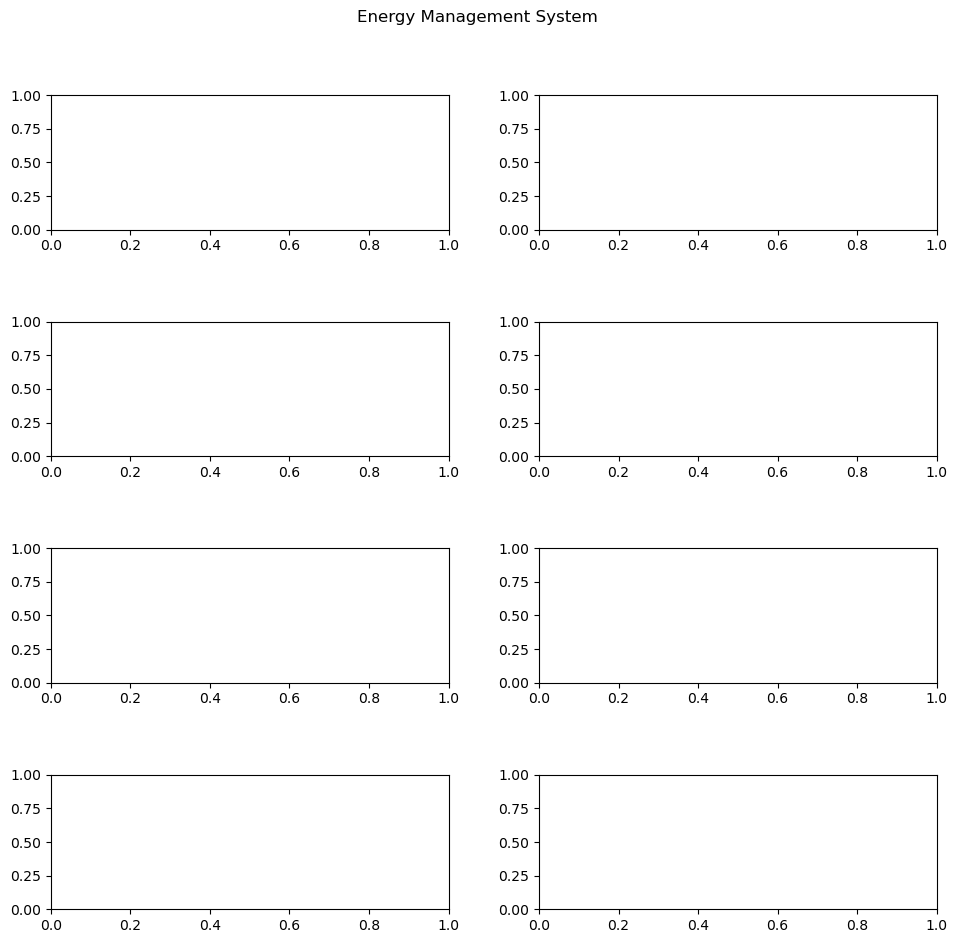

In [8]:
from utils_functions.funcionesEMS import follow_ref_rew_1, follow_ref_rew_2, follow_ref_rew_3

model1 = torch.load(path1 + '/policy.pt')
scaler1 = joblib.load(path1 + '/scaler.pkl')

model2 = torch.load(path2 + '/policy.pt')
scaler2 = joblib.load(path2 + '/scaler.pkl')

model3 = torch.load(path3 + '/policy.pt')
scaler3 = joblib.load(path3 + '/scaler.pkl')

rwd_fun_1 = follow_ref_rew_1 #lambda s, a, s_next: rwd_fun(s, a, s_next, 0)
rwd_fun_2 = follow_ref_rew_1 #lambda s, a, s_next: rwd_fun(s, a, s_next, 1)
rwd_fun_3 = follow_ref_rew_1 #lambda s, a, s_next: rwd_fun(s, a, s_next, 2)

mdl = EMS_env()
results = mdl.compare_policies([(model1, scaler1), (model2, scaler2), (model3, scaler3)], 288, [rwd_fun_1, rwd_fun_2, rwd_fun_3]) 

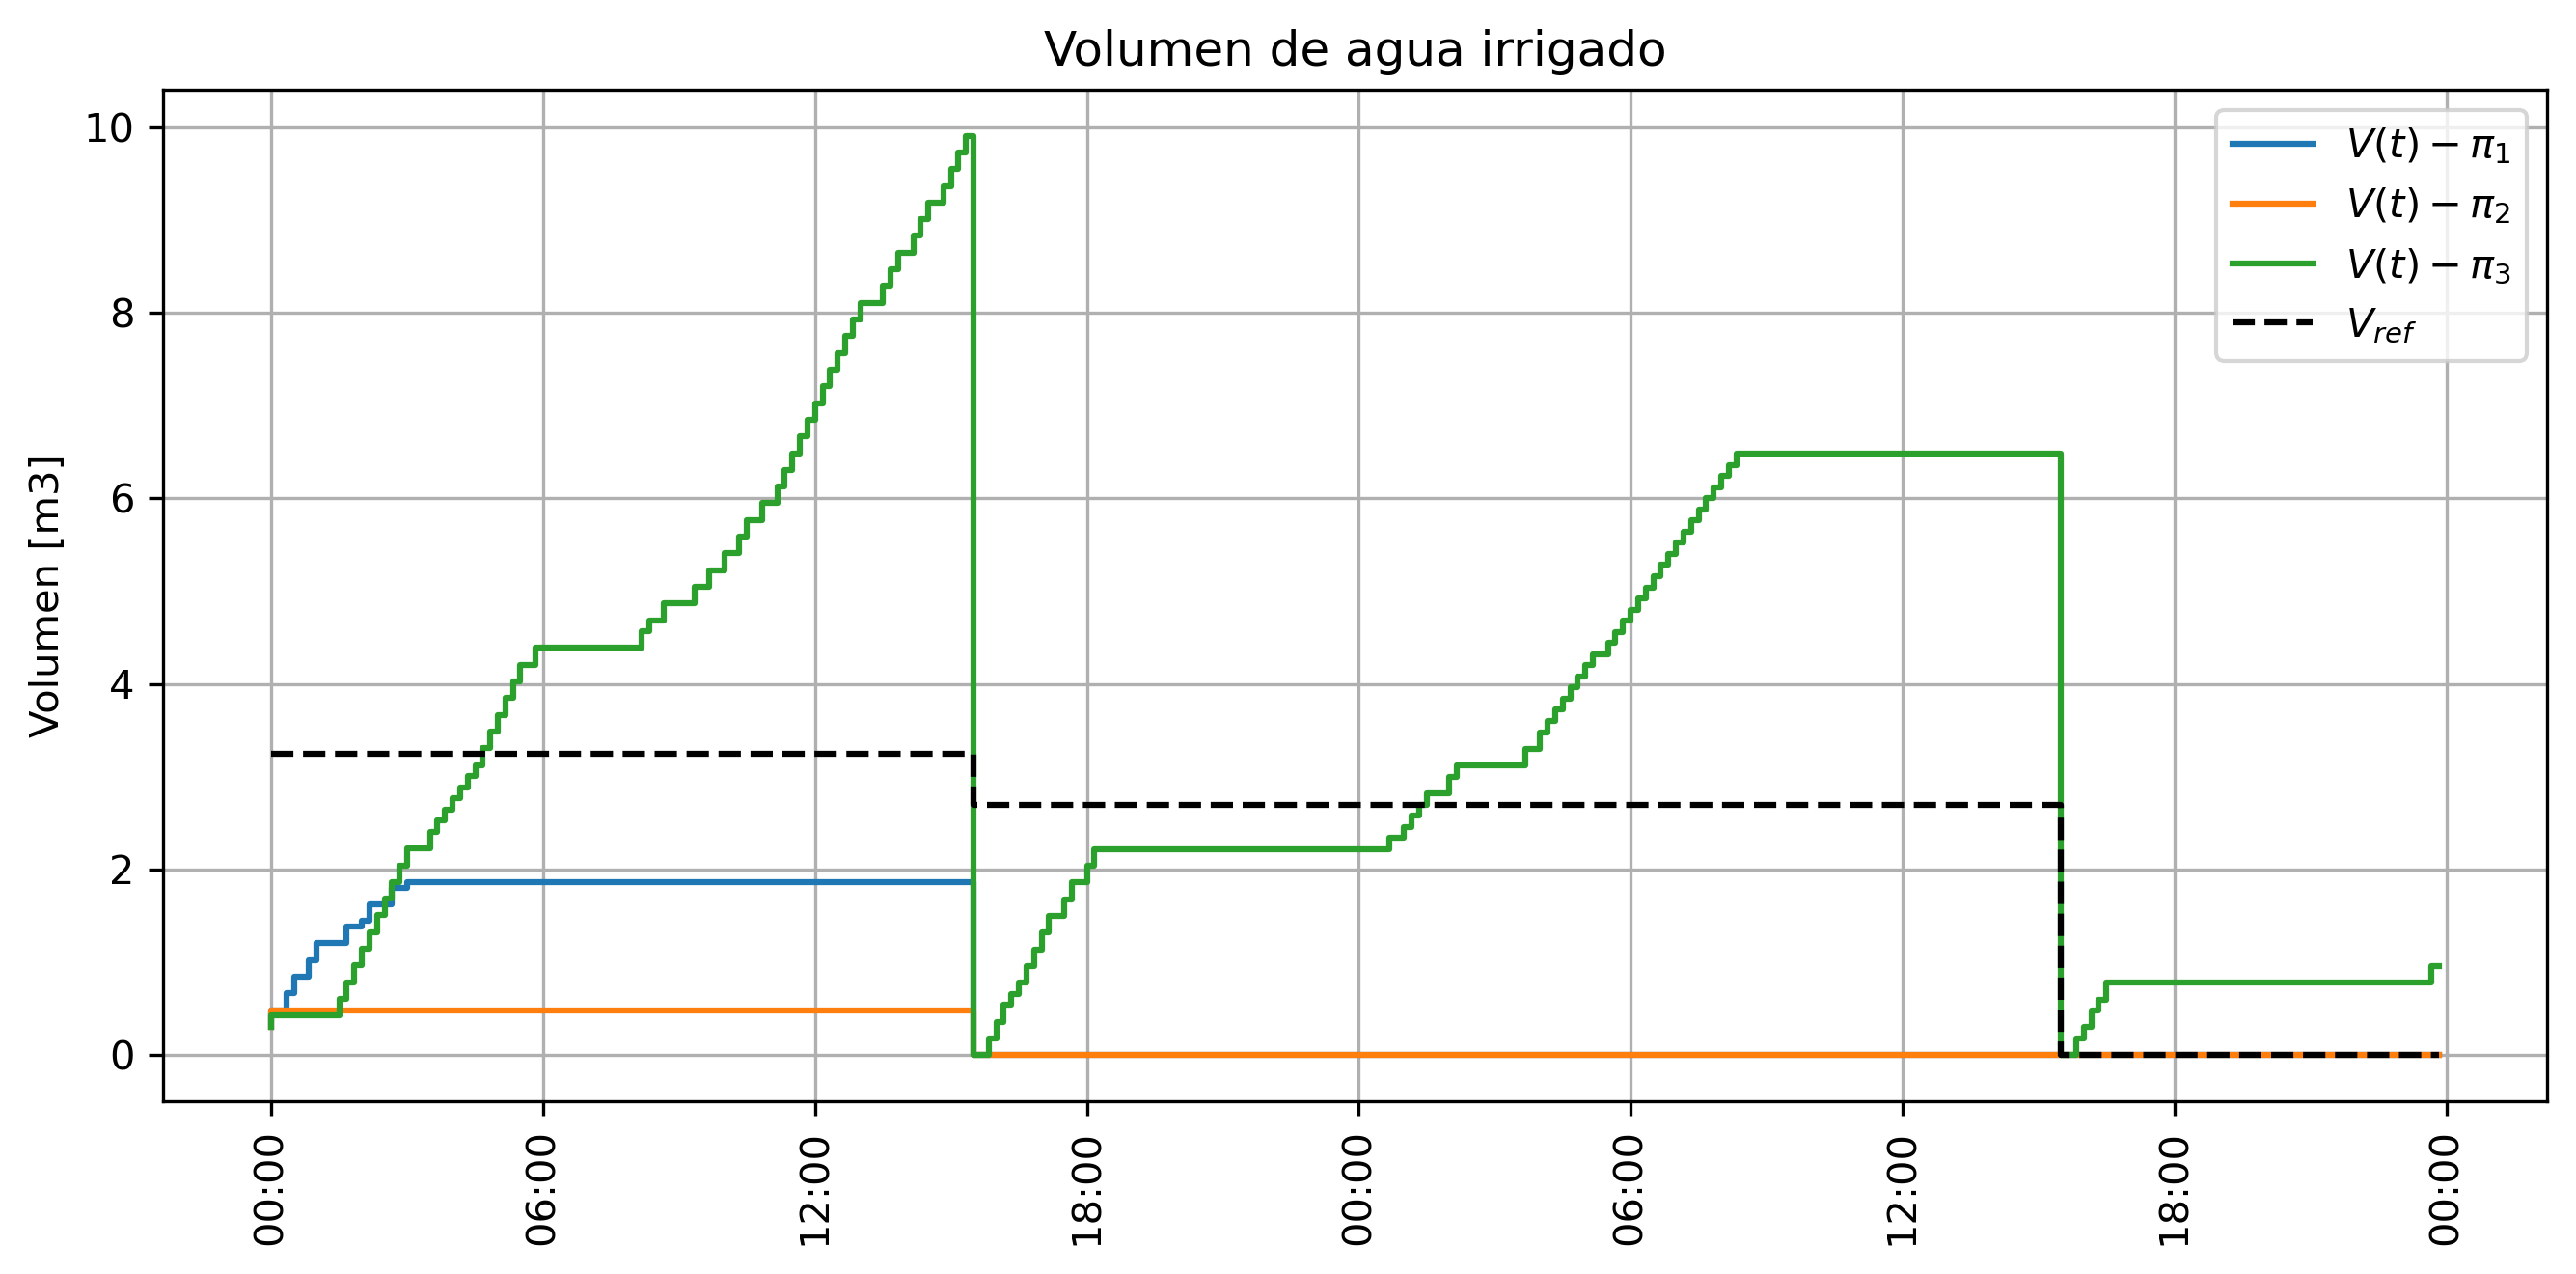

In [9]:
# Step 1: Create a list of datetime objects
start_time = datetime.datetime(2021, 1, 1, 0, 0)
time_range = [start_time + datetime.timedelta(minutes=10*i) for i in range(2*24*6)]
time_range = mdates.date2num(time_range)

fig, ax = plt.subplots(dpi=300)
fig.set_size_inches(9.0, 4.5)

for idx, result in enumerate(results):
    ax.step(time_range, result[0][:-1,4], label = f"$V(t) - \pi_{idx+1}$")
plt.xticks(rotation=90)
ax.step(time_range, results[0][0][:-1,0], label = f"$V_{{{'ref'}}}$", color = 'black', linestyle = '--')
time_format = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(time_format)
ax.set_title("Volumen de agua irrigado")
ax.set_ylabel("Volumen [m3]")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("./figures/volumen_agua_irrigado.png", dpi=300)

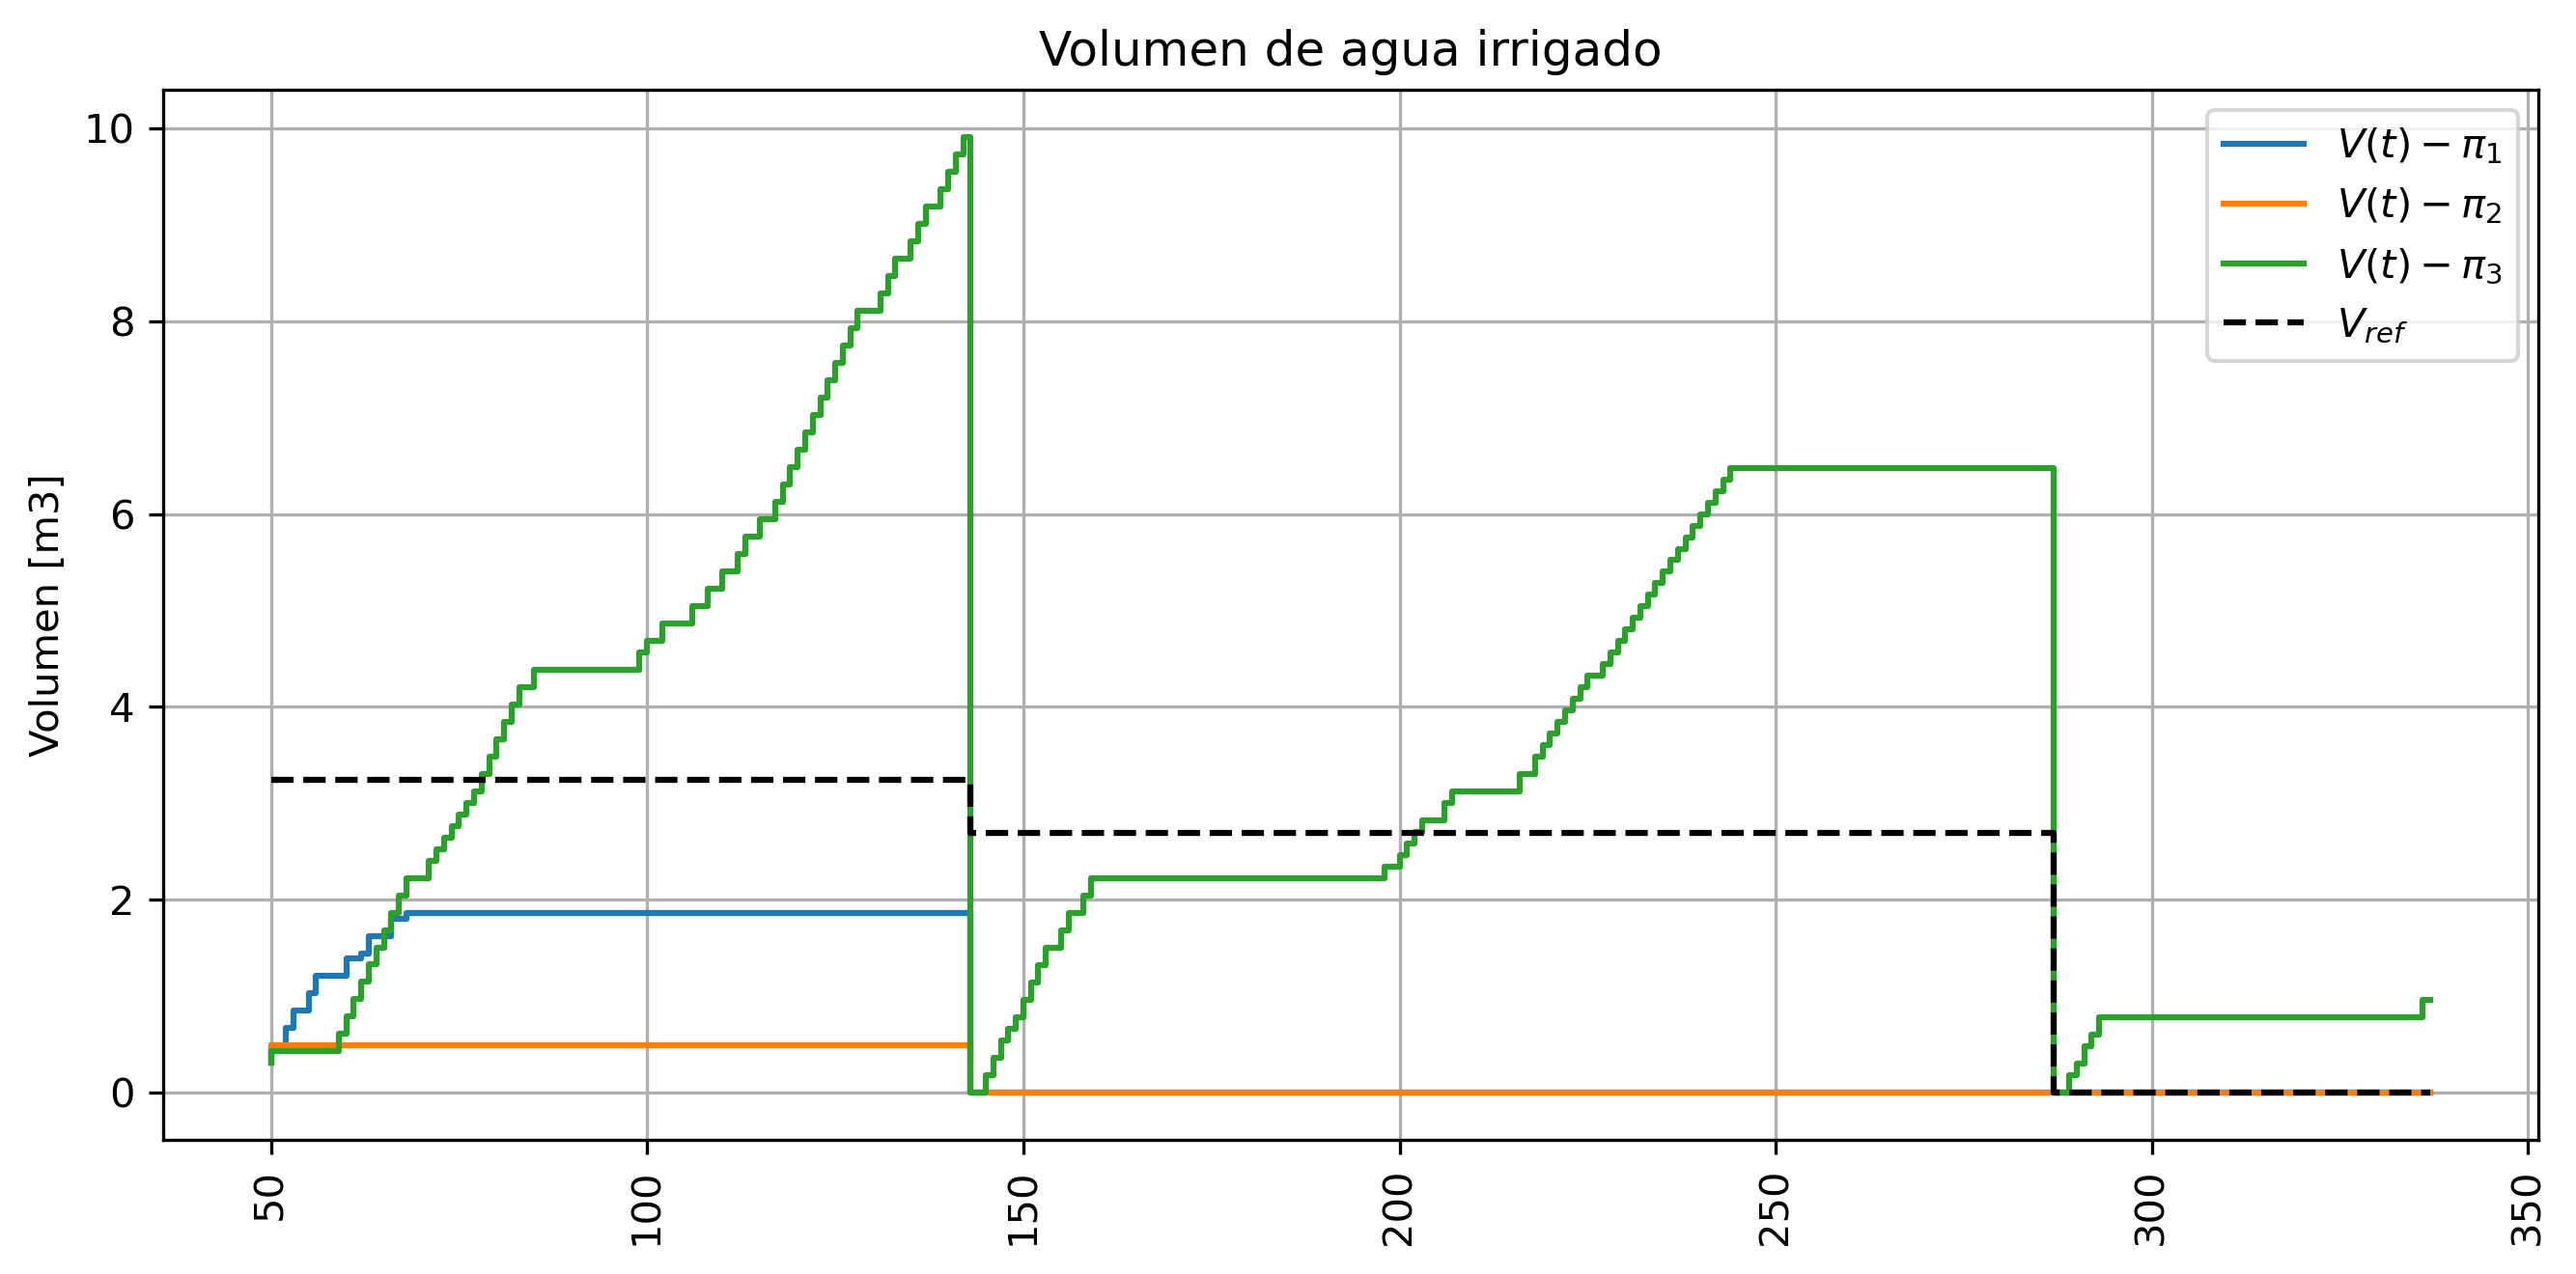

In [10]:
# Step 1: Create a list of datetime objects
t_start = int(results[0][0][:-1,-1][0])
time_range = range(t_start, (144*2 + t_start))

fig, ax = plt.subplots(dpi=300)
fig.set_size_inches(9.0, 4.5)

for idx, result in enumerate(results):
    ax.step(time_range, result[0][:-1,4], label = f"$V(t) - \pi_{idx+1}$")
plt.xticks(rotation=90)
ax.step(time_range, results[0][0][:-1,0], label = f"$V_{{{'ref'}}}$", color = 'black', linestyle = '--')

ax.set_title("Volumen de agua irrigado")
ax.set_ylabel("Volumen [m3]")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("./figures/volumen_agua_irrigado.png", dpi=300)

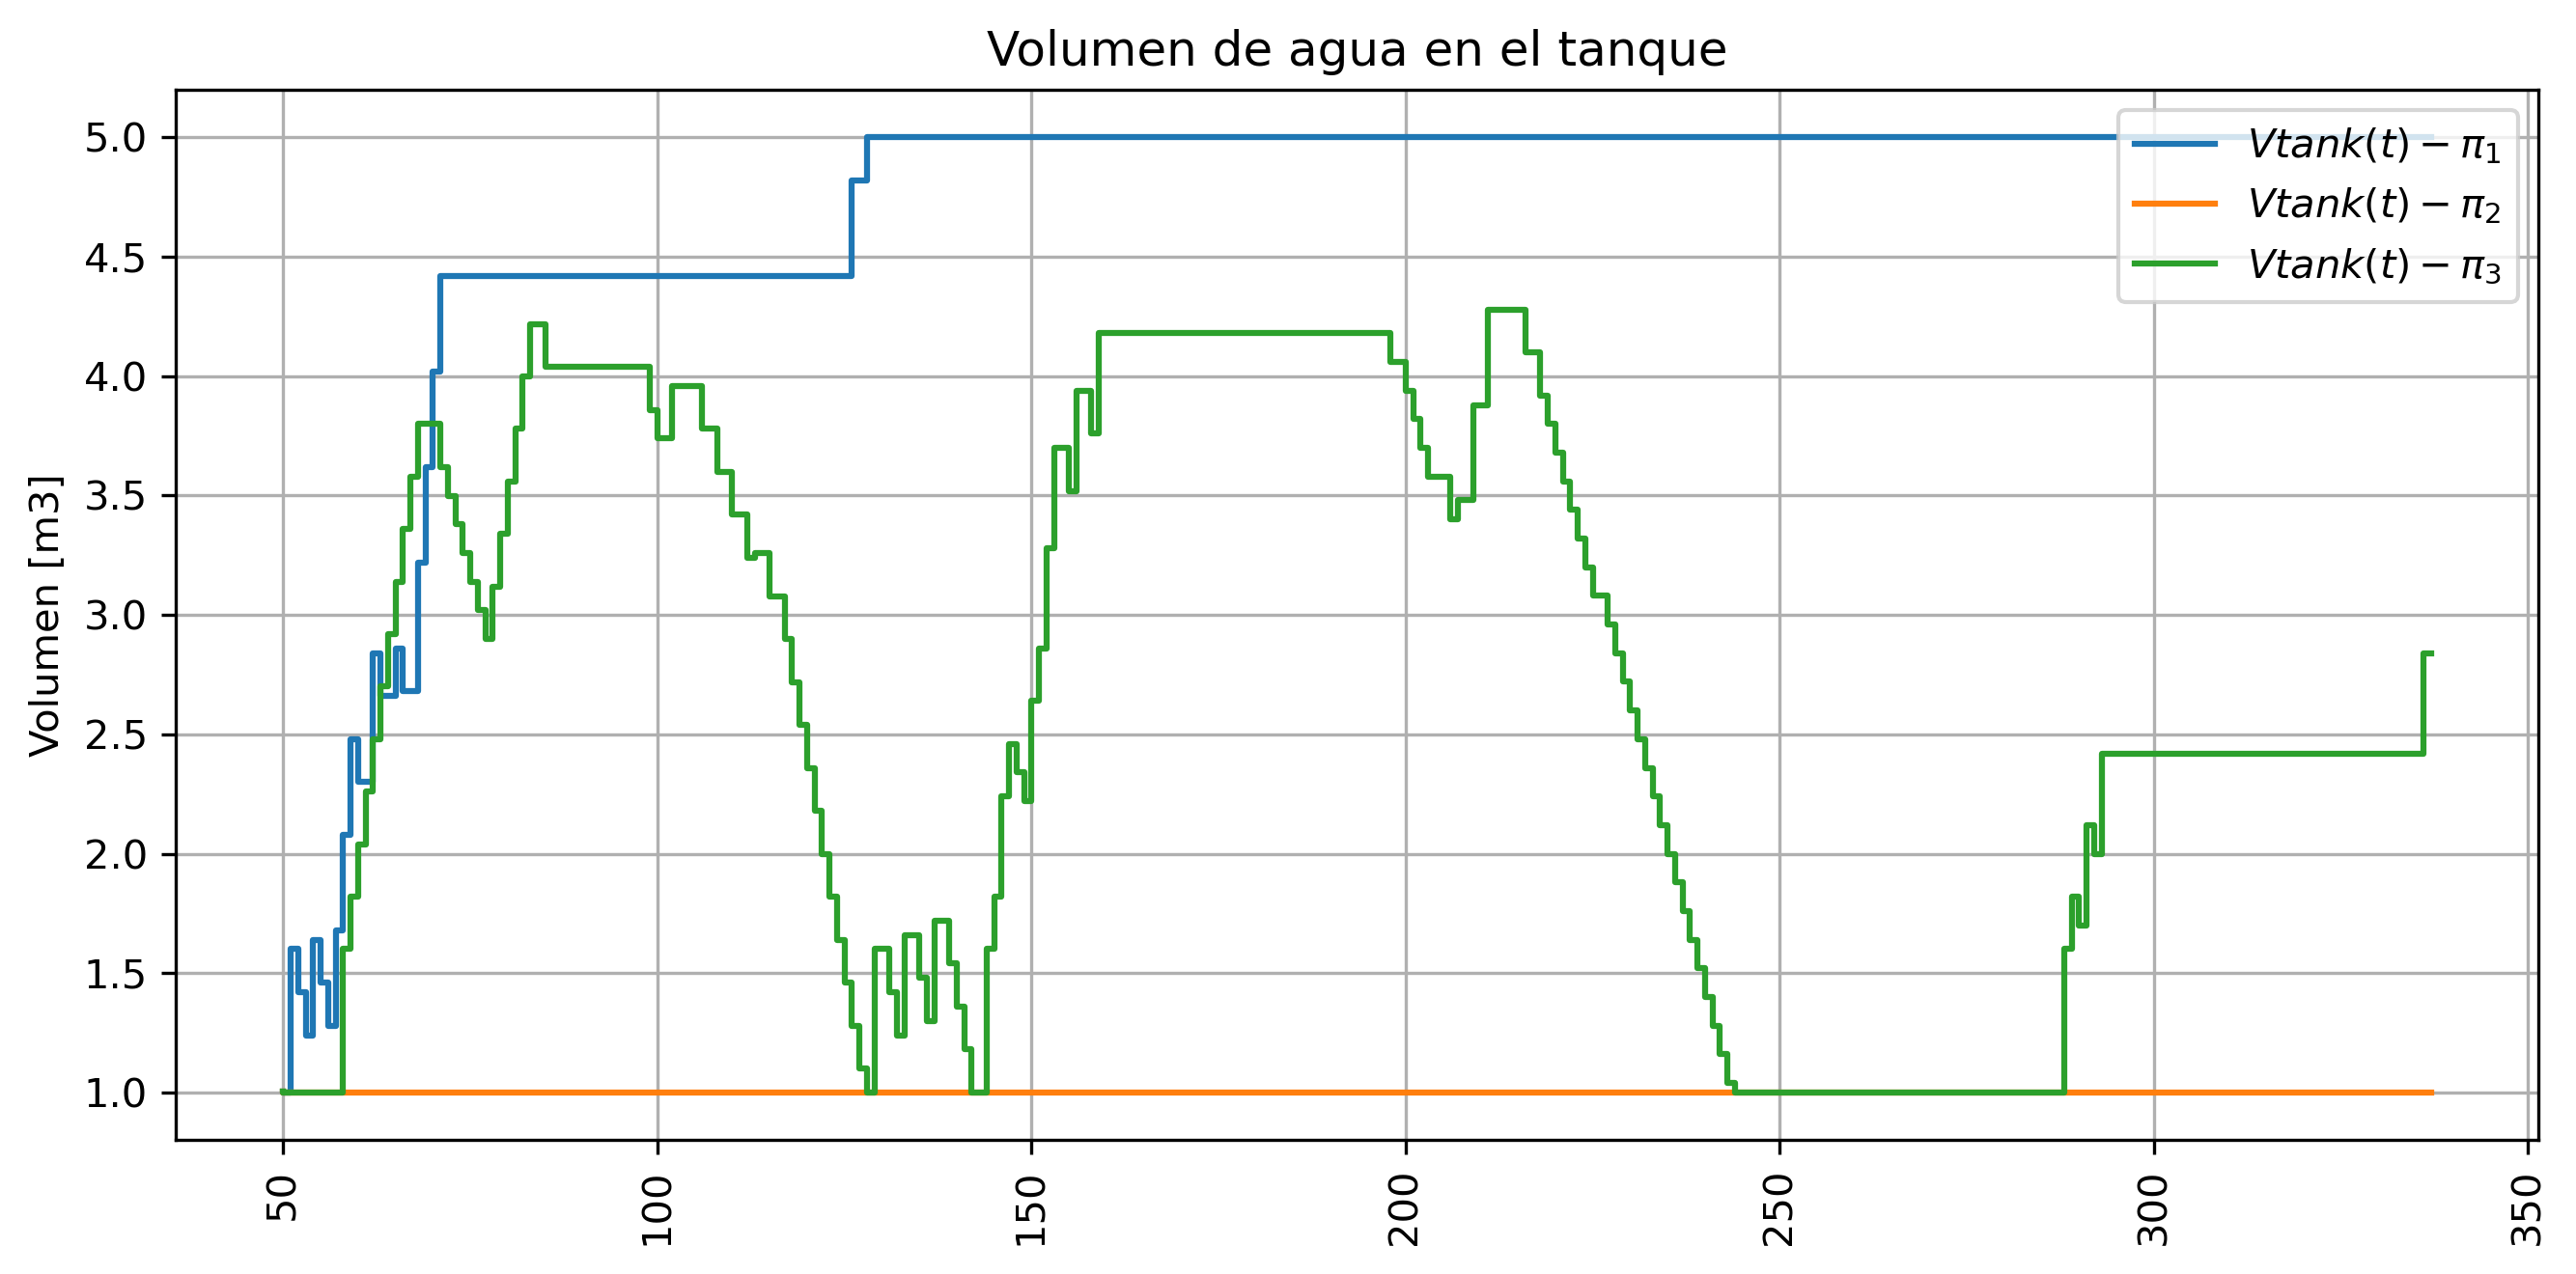

In [11]:
# Step 1: Create a list of datetime objects
t_start = int(results[0][0][:-1,-1][0])
time_range = range(t_start, (144*2 + t_start))

fig, ax = plt.subplots(dpi=300)
fig.set_size_inches(9.0, 4.5)

for idx, result in enumerate(results):
    ax.step(time_range, result[0][:-1,1], label = f"$Vtank(t) - \pi_{idx+1}$")
plt.xticks(rotation=90)
#ax.step(time_range, results[0][0][:-1,2], label = f"$V_{{{'ref'}}}$", color = 'black', linestyle = '--')

ax.set_title("Volumen de agua en el tanque")
ax.set_ylabel("Volumen [m3]")
plt.legend(loc = 'upper right')
plt.grid()
plt.tight_layout()
plt.savefig("./figures/volumen_agua_irrigado.png", dpi=300)

In [12]:
results[0][0][:-1,-1][0]

50.0

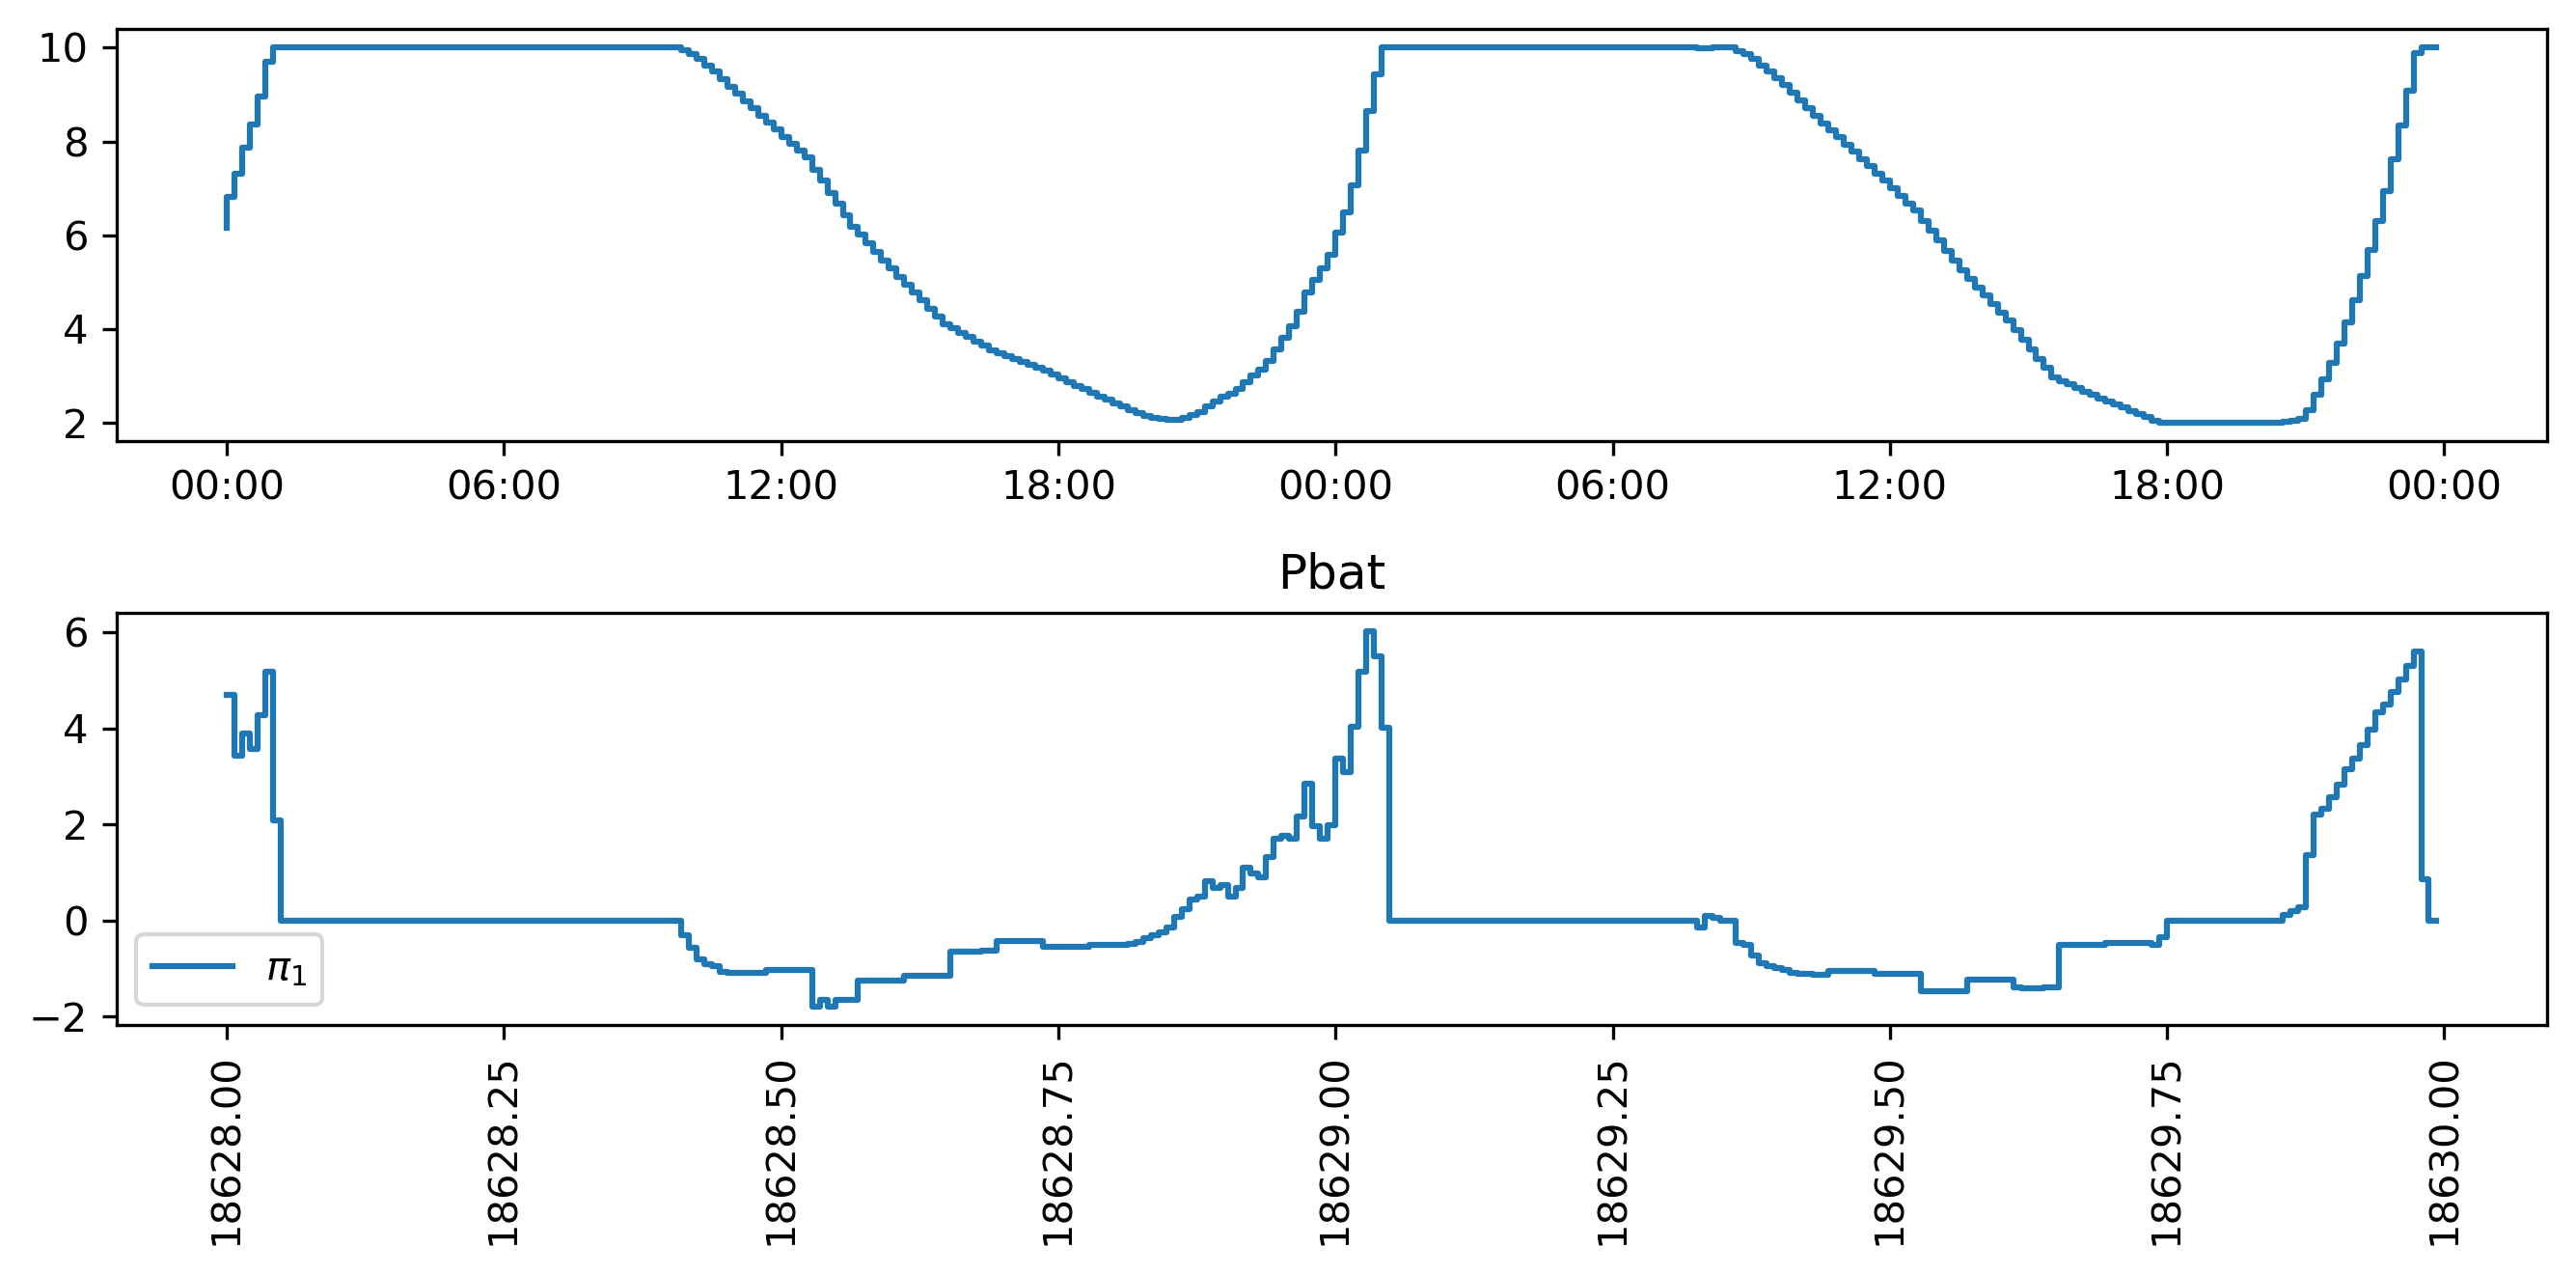

In [13]:
# Step 1: Create a list of datetime objects
start_time = datetime.datetime(2021, 1, 1, 0, 0)
time_range = [start_time + datetime.timedelta(minutes=10*i) for i in range(2*24*6)]
time_range = mdates.date2num(time_range)
fig, axs = plt.subplots(2, 1, dpi=300)
fig.set_size_inches(9.0, 4.5)

for i, result in enumerate(results[0:1]):
    #ax.step(time_range, np.diff(result[0][:,2])*6, label = f"$\pi_{i+1}$")
    axs[0].step(time_range, (result[0][:-1,2]), label = f"$\pi_{i+1}$")
#    ax[0].step(time_range, result[0][:-1,8], label = f"$\pi_{i+1}$")

for i, result in enumerate(results[0:1]):
    #ax.step(time_range, np.diff(result[0][:,2])*6, label = f"$\pi_{i+1}$")
#    axs[1].step(time_range, (result[0][:-1,2]), label = f"$\pi_{i+1}$")
    #axs[1].step(time_range, result[0][:-1,8], label = f"$\pi_{i+1}$")
    #axs[1].step(time_range, result[0][:-1,6], label = f"$\pi_{i+1}$")
    axs[1].step(time_range, result[0][:-1,8], label = f"$\pi_{i+1}$")

plt.xticks(rotation=90)
time_format = mdates.DateFormatter('%H:%M')
axs[0].xaxis.set_major_formatter(time_format)
plt.title("Pbat")
plt.legend()
fig.tight_layout()

In [14]:
scaler1.mean_, scaler1.var_

(array([1.60680158e+00, 2.99730512e+00, 5.96734915e+00, 1.49440000e+01,
        7.98160840e-01, 5.08274830e+01, 2.62431471e+00, 8.58726855e-01,
        1.64610610e+00, 1.69130767e-02, 7.19415000e+01]),
 array([1.28496909e+00, 1.33616880e+00, 5.51049561e+00, 1.25636864e+02,
        6.34705800e-01, 1.38373114e+03, 1.04967641e+01, 9.27632148e-02,
        9.74000995e+00, 1.09235324e-02, 1.75189468e+03]))

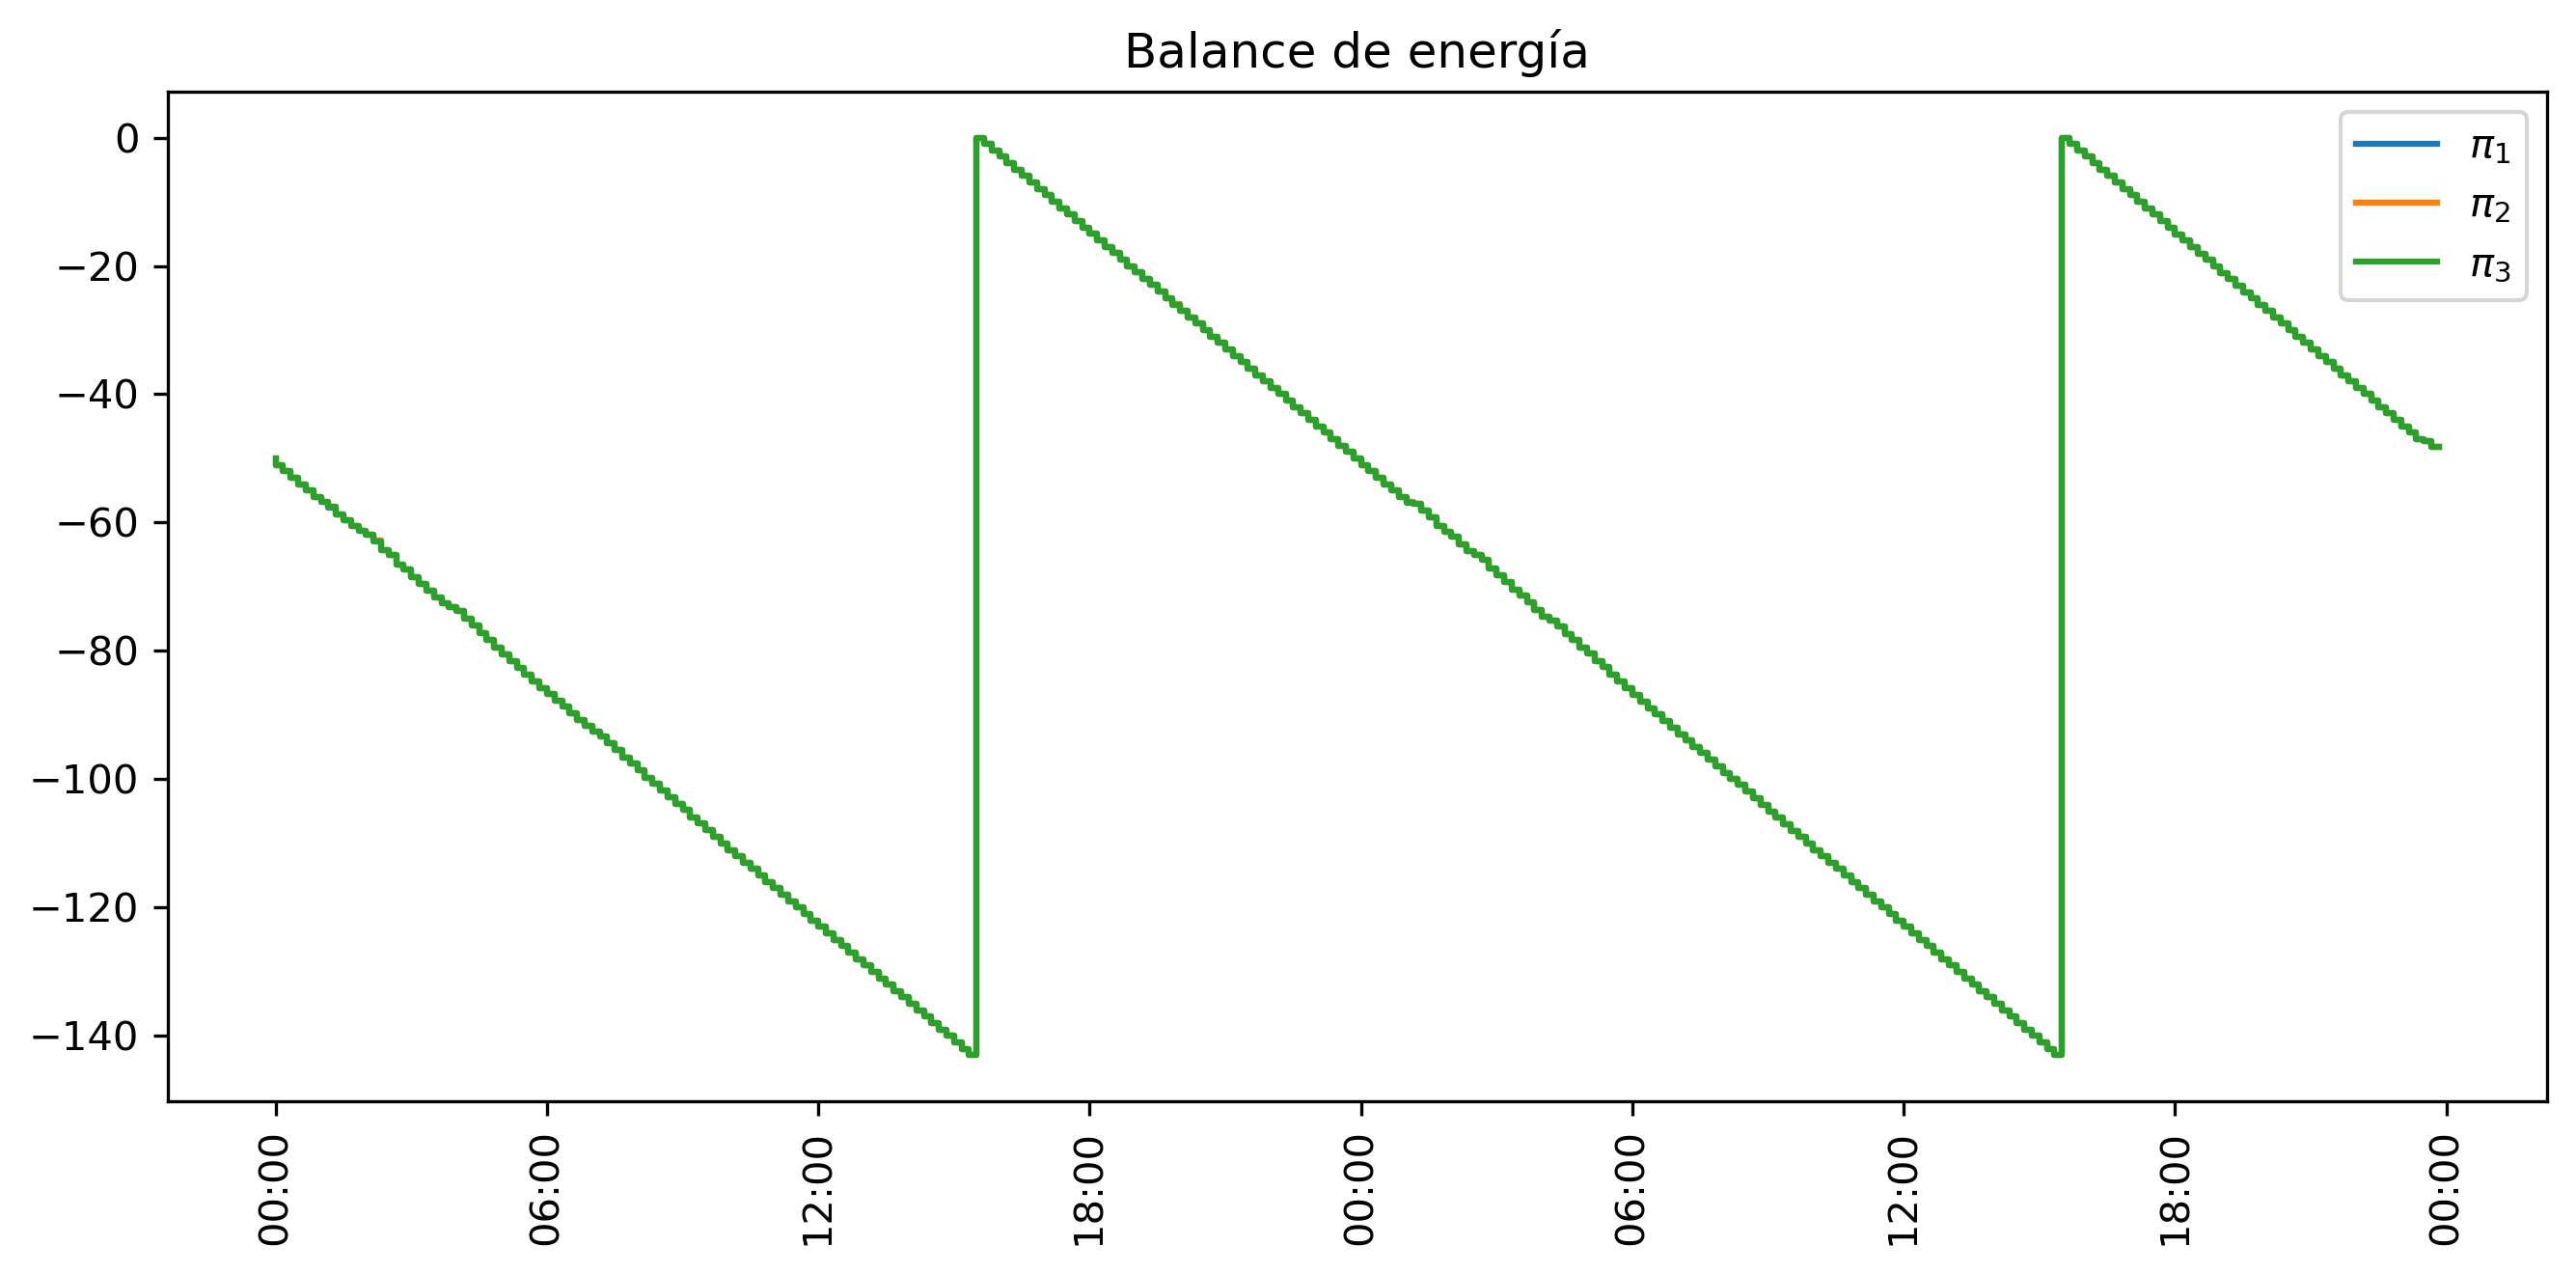

In [15]:
# Step 1: Create a list of datetime objects
start_time = datetime.datetime(2021, 1, 1, 0, 0)
time_range = [start_time + datetime.timedelta(minutes=10*i) for i in range(2*24*6)]
time_range = mdates.date2num(time_range)

fig, ax = plt.subplots(dpi=300)
fig.set_size_inches(9.0, 4.5)
for idx, result in enumerate(results):
    #energy_balance = result[0][:-1,6] - result[0][:-1,7] - result[1][:,1]*20/1000
    energy_balance = result[0][:-1, 9] - result[0][:-1, 10]
    ax.step(time_range, energy_balance, label = f"$\pi_{idx+1}$")

time_format = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(time_format)
plt.xticks(rotation=90)
plt.title("Balance de energía")
plt.legend()
fig.tight_layout()

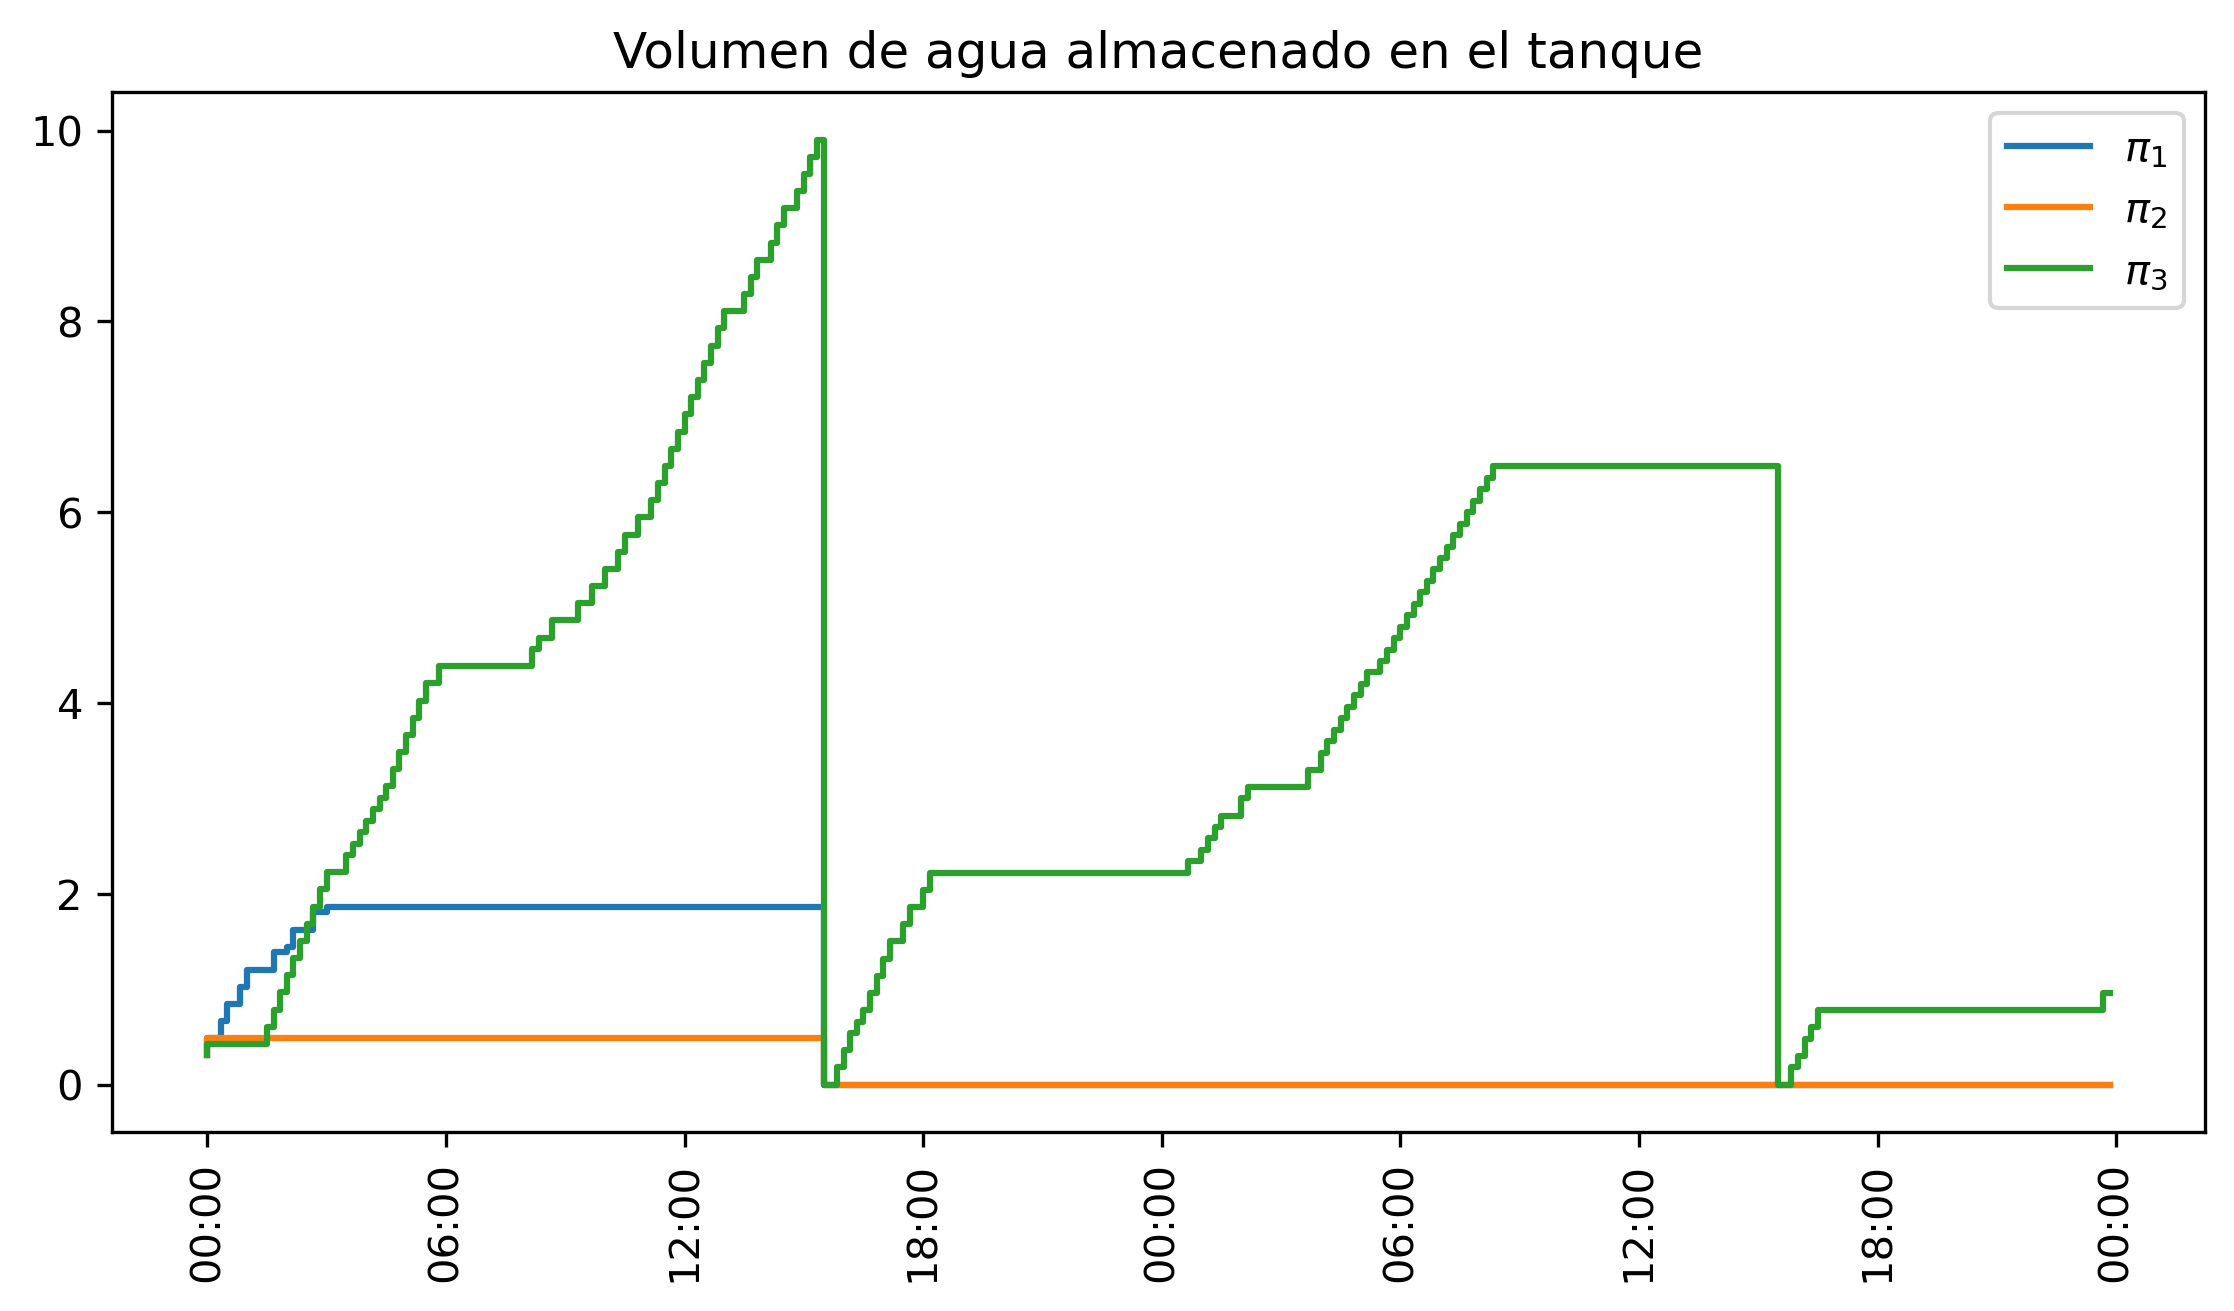

In [16]:
start_time = datetime.datetime(2021, 1, 1, 0, 0)
time_range = [start_time + datetime.timedelta(minutes=10*i) for i in range(2*24*6)]
time_range = mdates.date2num(time_range)

fig, ax = plt.subplots(dpi=300)
fig.set_size_inches(9.0, 4.5)
for idx, result in enumerate(results):
    ax.step(time_range, result[0][:-1,4], label = f"$\pi_{idx+1}$")
time_format = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(time_format)
plt.xticks(rotation=90)
plt.title("Volumen de agua almacenado en el tanque")
plt.legend()

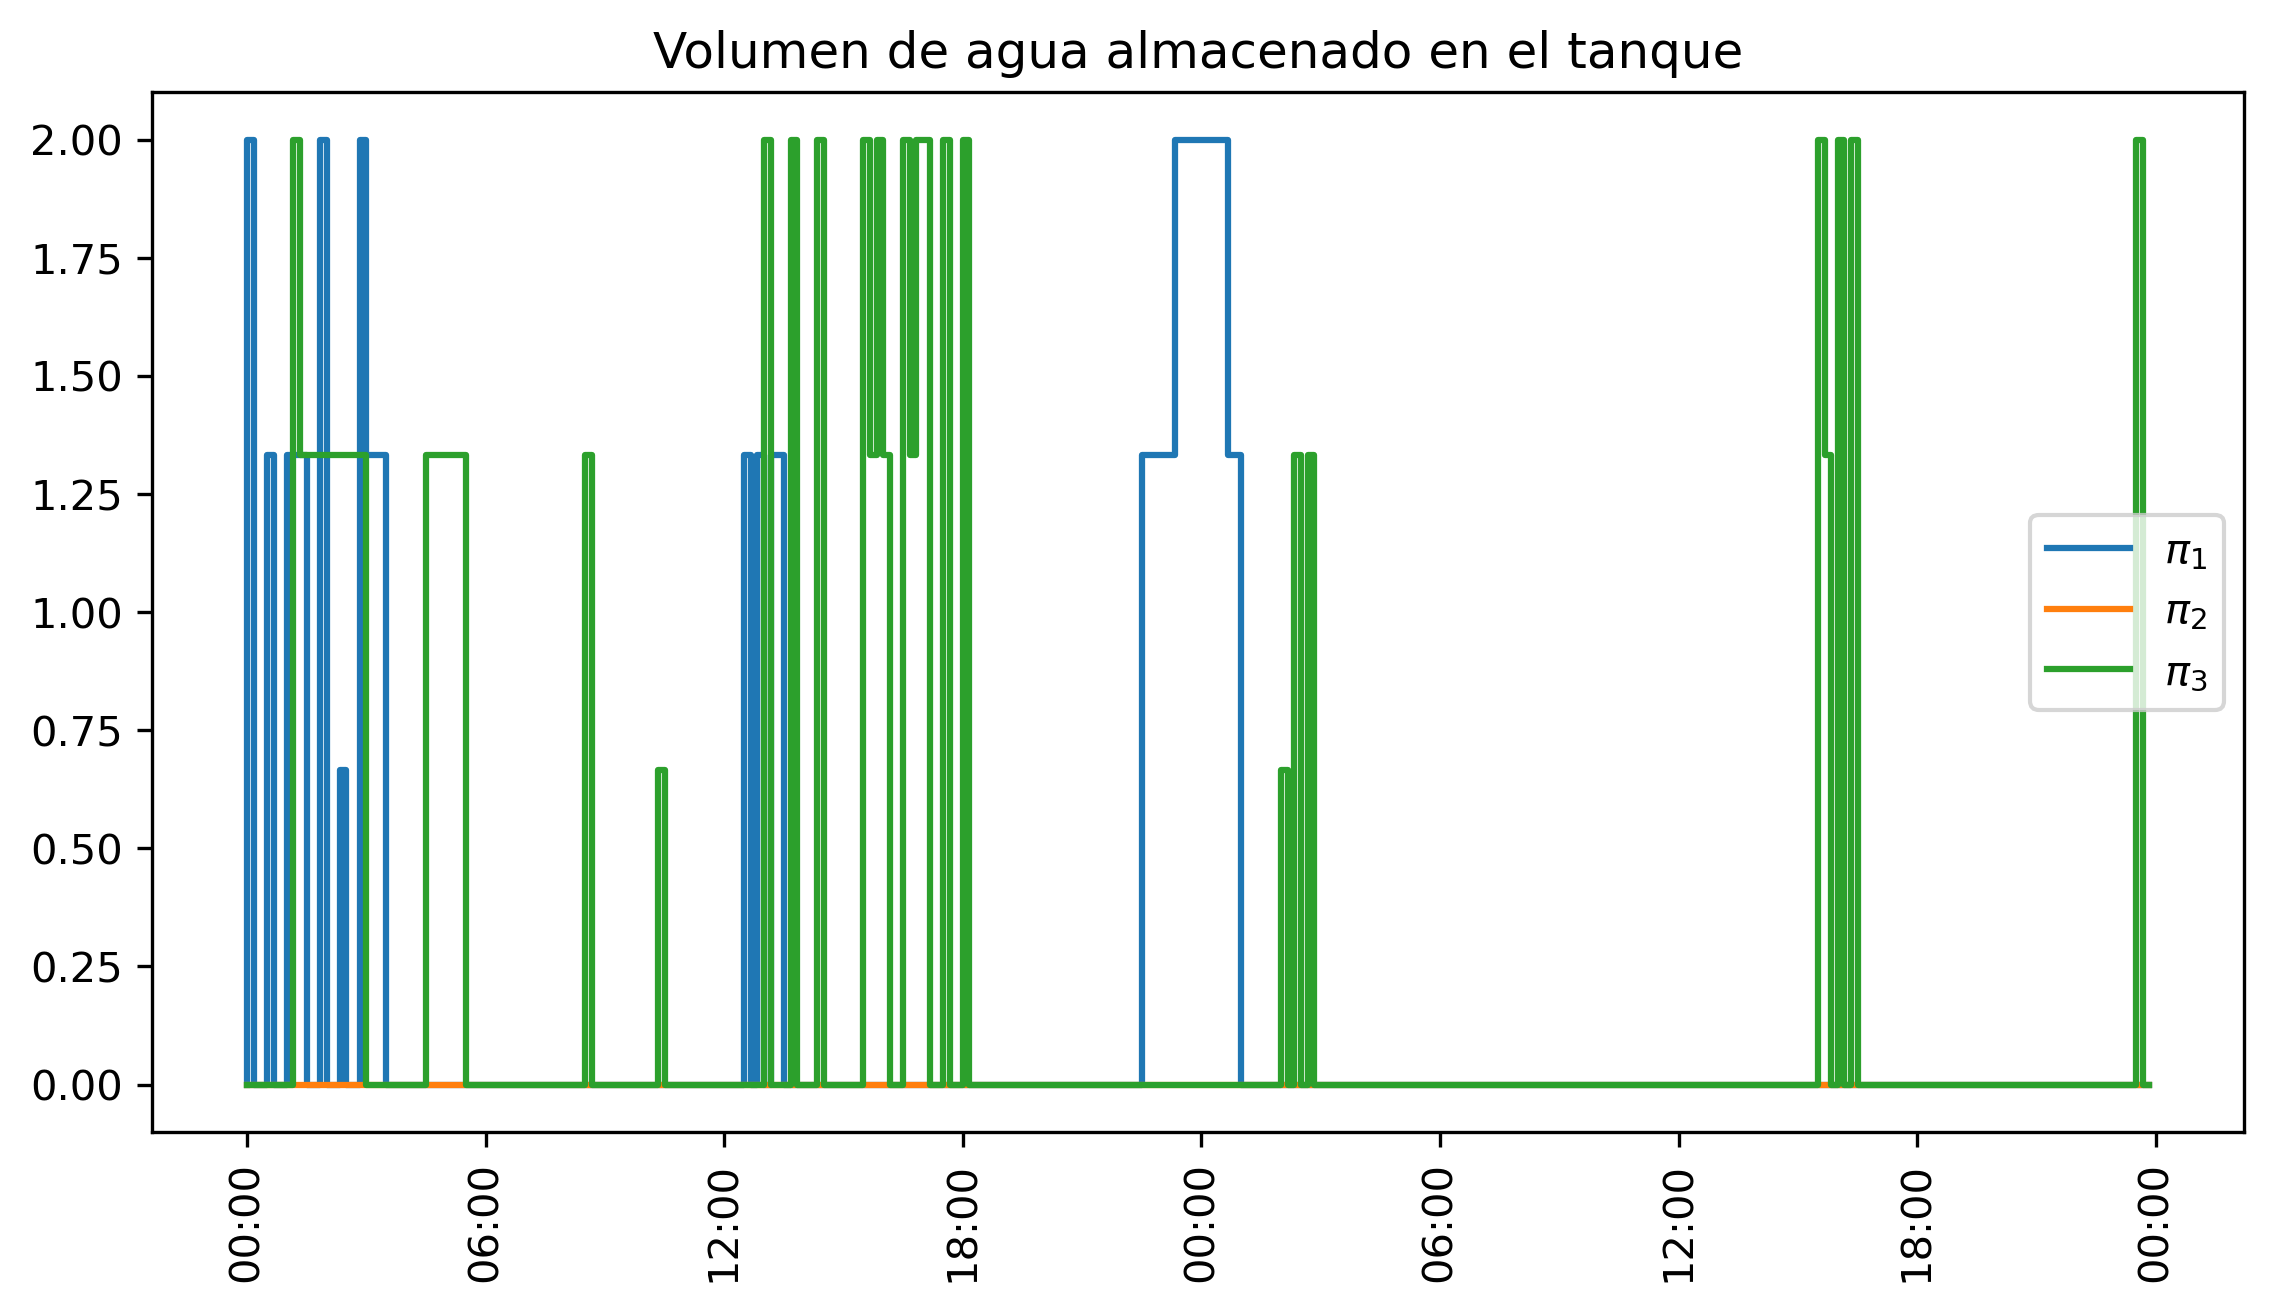

In [17]:
start_time = datetime.datetime(2021, 1, 1, 0, 0)
time_range = [start_time + datetime.timedelta(minutes=10*i) for i in range(2*24*6)]
time_range = mdates.date2num(time_range)

fig, ax = plt.subplots(dpi=300)
fig.set_size_inches(9.0, 4.5)
for idx, result in enumerate(results):
    ax.step(time_range, (result[1][:,1])*20/1000, label = f"$\pi_{idx+1}$")
time_format = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(time_format)
plt.xticks(rotation=90)
plt.title("Volumen de agua almacenado en el tanque")
plt.legend()

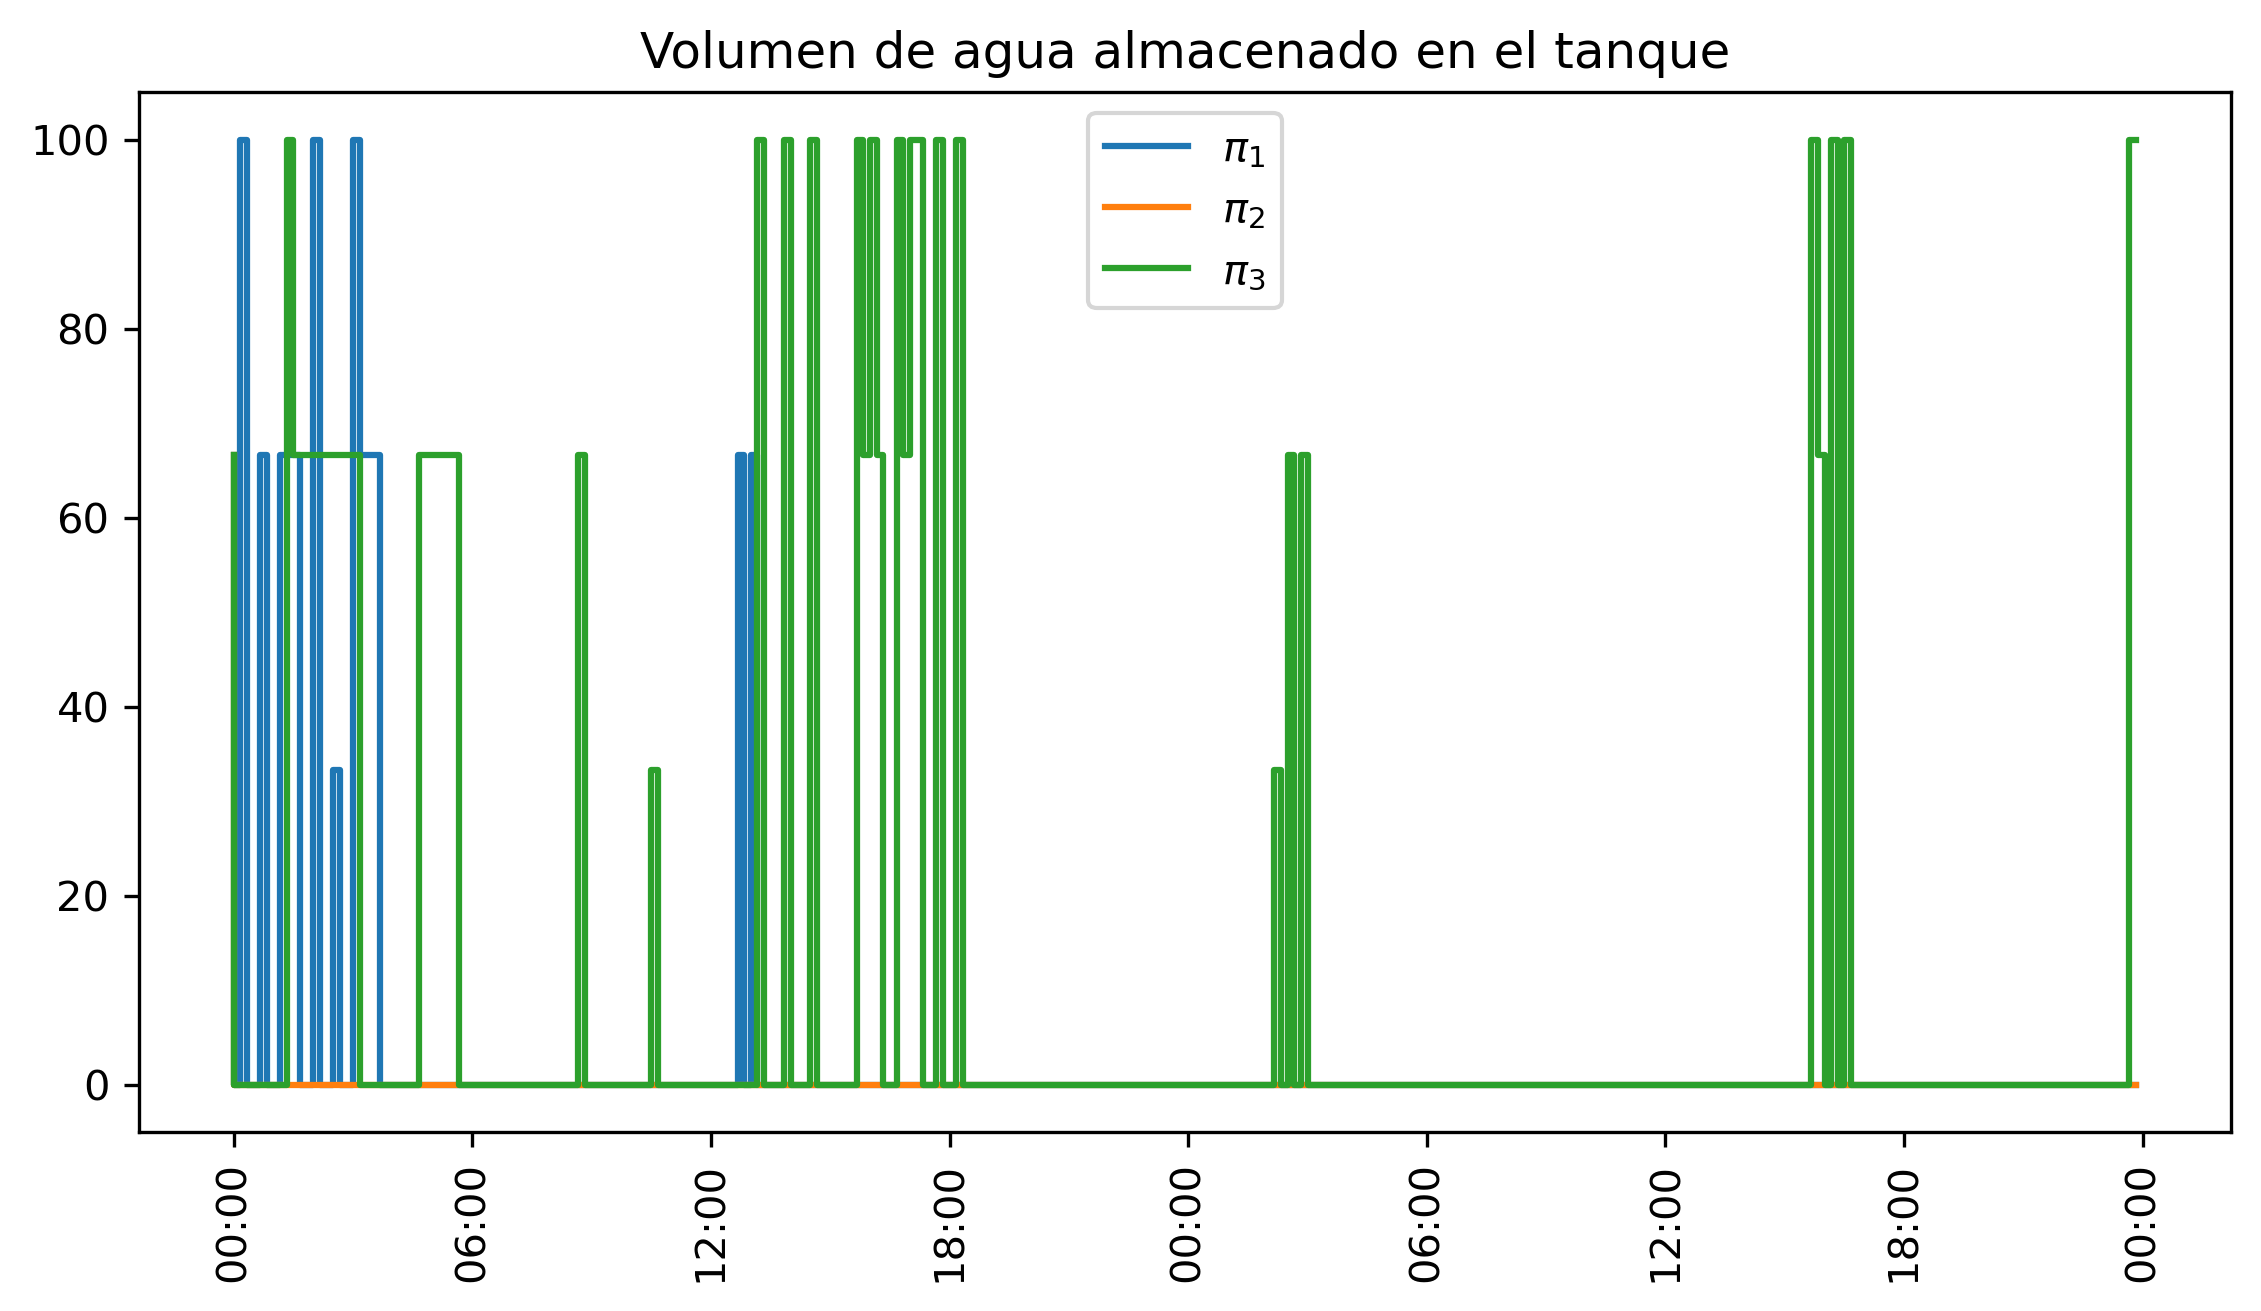

In [18]:
start_time = datetime.datetime(2021, 1, 1, 0, 0)
time_range = [start_time + datetime.timedelta(minutes=10*i) for i in range(2*24*6)]
time_range = mdates.date2num(time_range)

fig, ax = plt.subplots(dpi=300)
fig.set_size_inches(9.0, 4.5)
for idx, result in enumerate(results):
    ax.step(time_range, result[0][:-1,5], label = f"$\pi_{idx+1}$")
time_format = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(time_format)
plt.xticks(rotation=90)
plt.title("Volumen de agua almacenado en el tanque")
plt.legend()

In [19]:
idx = 287
L = [1, 2, 3, 4, 5]
L[0:2]

[1, 2]

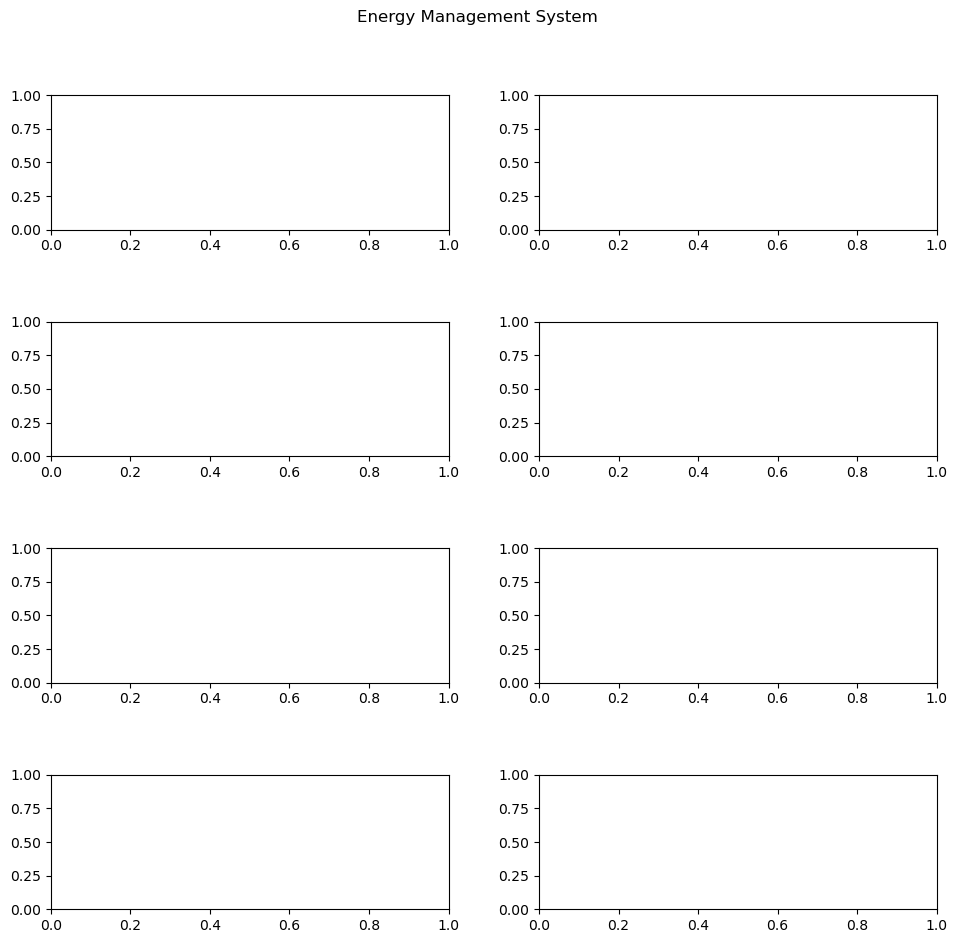

In [20]:
### compare the results of the policies  

N = 200 # number of executions  

errors = np.zeros((3, 2*N))
average_soe = np.zeros_like(errors)
average_vtank = np.zeros_like(errors)
env = EMS_env()
options = {"t_init":0}
for model_idx, policy in enumerate([model1, model2, model3]):
    for i in range(N):
        states, actions, rews = env.sample_trajectory(policy, options, 288)
        average_soe[model_idx,i:i+2] = np.array([np.mean(states[:144, 2]), np.mean(states[144:, 2])])
        average_vtank[model_idx,i:i+2] = np.array([np.mean(states[:144, 1]), np.mean(states[144:, 1])])
        errors[model_idx,i:i+2] = np.array([states[143, 0] - states[143, 4], states[287, 0] - states[287, 4]])


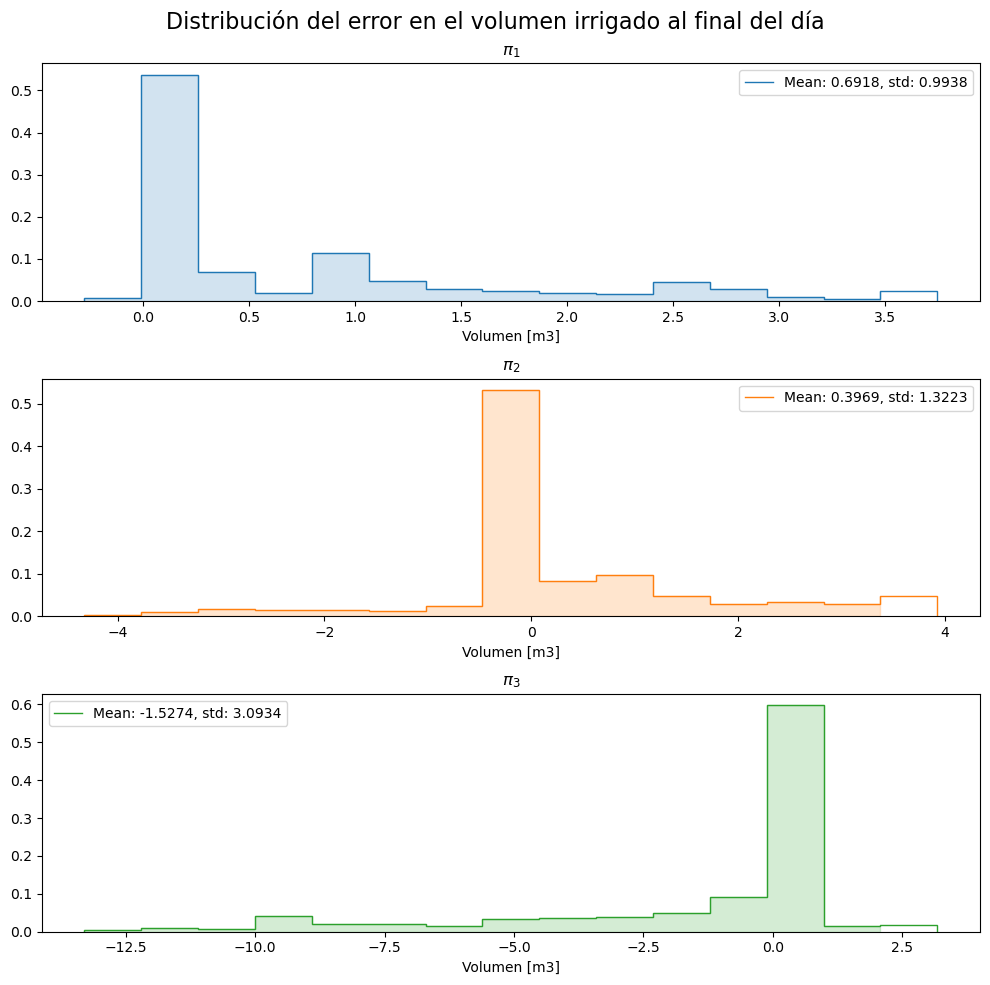

In [22]:
fig, axs = plt.subplots(3, 1, figsize=(10, 10))
colors = ['tab:blue', 'tab:orange', 'tab:green']

for idx, ax in enumerate(axs):
    #ax.set_xlim(-10, 10)
    counts, bins = np.histogram(errors[idx], bins=15)
    ax.stairs(counts/400, 
              bins, 
              label = f"Mean: {np.mean(errors[idx]):.4f}, std: {np.std(errors[idx]):.4f}", 
              color=colors[idx])
    ax.fill_between(bins[:-1], counts/400, alpha=0.2, color=colors[idx], step='post')
    ax.legend()
    ax.set_title(f"$\pi_{idx+1}$")
    ax.set_xlabel("Volumen [m3]")

fig.suptitle('Distribución del error en el volumen irrigado al final del día', fontsize=16)
fig.tight_layout()
fig.savefig("./figures/volumen agua.png", dpi=300)

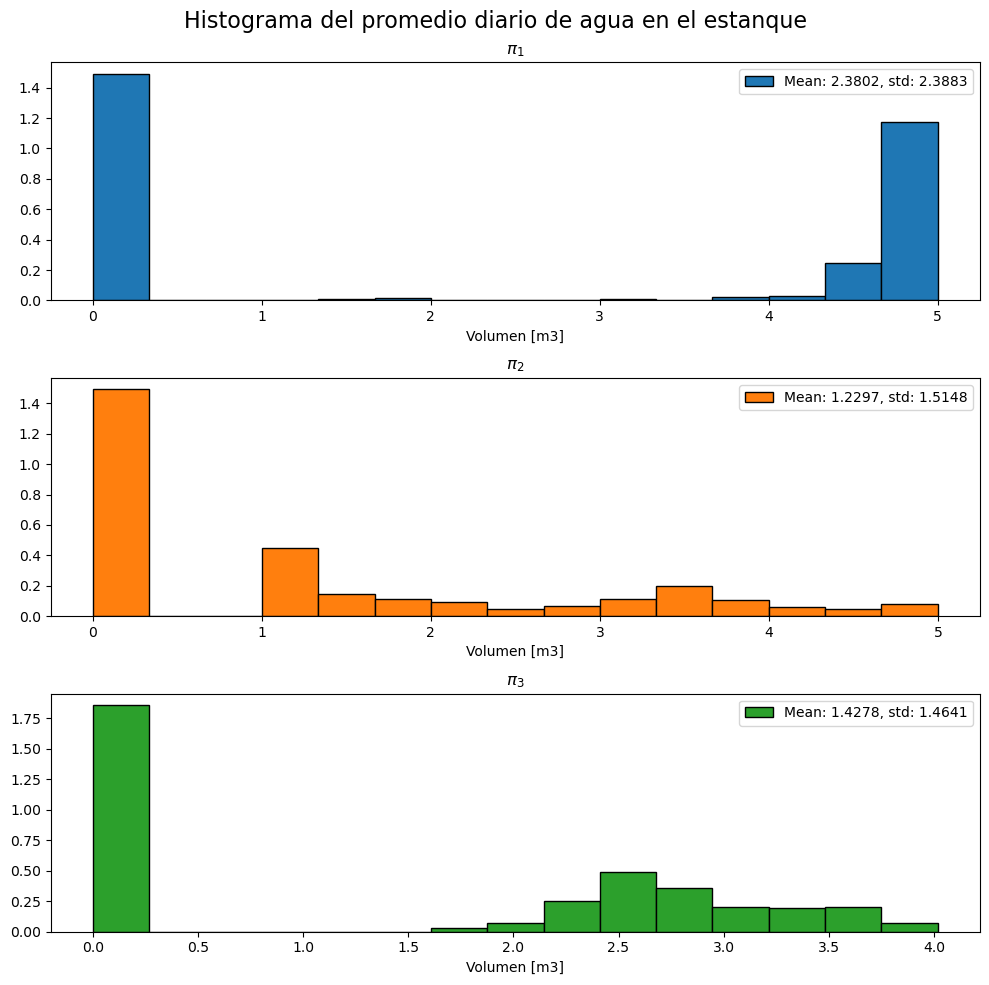

In [28]:
fig, axs = plt.subplots(3, 1, figsize=(10, 10))

colors = ['tab:blue', 'tab:orange', 'tab:green']

for idx, ax in enumerate(axs):
    #ax.set_xlim(0, 35)
    ax.hist(average_vtank[idx], bins=15, edgecolor='black', 
            label = f"Mean: {np.mean(average_vtank[idx]):.4f}, std: {np.std(average_vtank[idx]):.4f}", 
            color=colors[idx], 
            density = True, 
            stacked = True)
    ax.legend()
    ax.set_title(f"$\pi_{idx+1}$")
    ax.set_xlabel("Volumen [m3]")
    
fig.suptitle('Histograma del promedio diario de agua en el estanque', fontsize=16)
fig.tight_layout()
fig.savefig("./figures/mean_wtank.png", dpi=300)

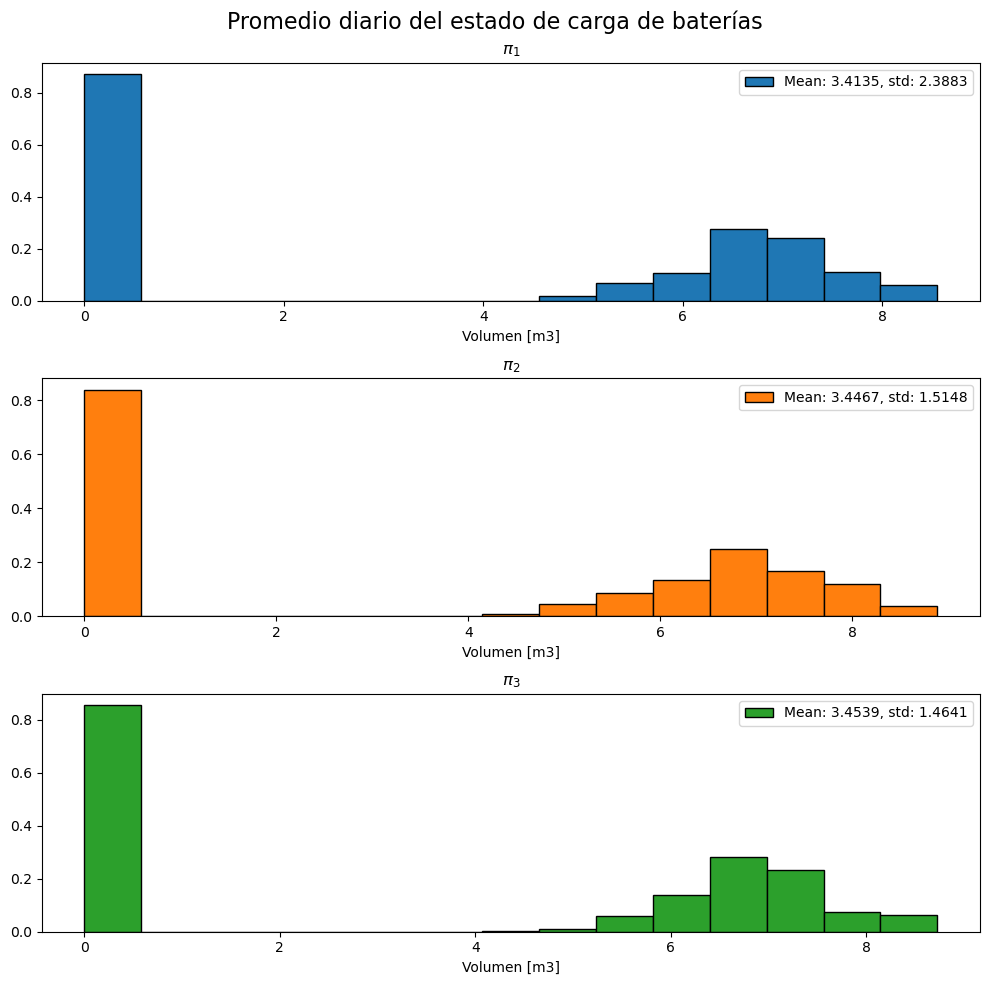

In [27]:
fig, axs = plt.subplots(3, 1, figsize=(10, 10))

colors = ['tab:blue', 'tab:orange', 'tab:green']

for idx, ax in enumerate(axs):
    #ax.set_xlim(0, 35)
    ax.hist(average_soe[idx], bins=15, edgecolor='black', 
            label = f"Mean: {np.mean(average_soe[idx]):.4f}, std: {np.std(average_vtank[idx]):.4f}", 
            color=colors[idx], 
            density = True, 
            stacked = True)
    ax.legend()
    ax.set_title(f"$\pi_{idx+1}$")
    ax.set_xlabel("Volumen [m3]")
    
fig.suptitle('Histograma del promedio diario del estado de carga de baterías', fontsize=16)
fig.tight_layout()
fig.savefig("./figures/deficit_energia.png", dpi=300)

In [24]:
average_deficit[2]


NameError: name 'average_deficit' is not defined